# Capstone Project - Stage 2, Week 7 (Module 18) - with Neural Networks

## Notebook changes:

- Switched to Sobol sampling from random sampling for lower dimension functions.
- For functions 1,2,5 added `if` statements to easily switch between UCB and EI acquisition functions.
- Suppressed warnings, since they were largely unhelpful or unsolvable.
- Major changes to contour and mesh plots for functions 1 and 2:
    - Found that the original mesh and contour plots, which used a different set of x candidates (made from an x-grid) to the set that were used in the neural network and GP model (generated using sobol sampling), differed greatly from what the GP model was showing. 
    - For example, the next query point that the model suggested did not line up with the maximum of the mesh or contour plot for the acquisition function. Additionally, the areas of low uncertainty were misaligned with the previously queried data points, and the GP mean estimation was showing false maxima.
    - Ended up using the sobol sampled set of x candidiates to generate the contour and mesh plots, meaning that visualisations lined up exactly with model behaviour and fixing these issues, giving a more accurate interpretation of results.
- Added a mesh plot to visualise the probabilistic predictions of the neural network (for functions 1 and 2 only).

## Importing libraries and initialising current week

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

from scipy.stats import norm
from scipy.spatial.distance import pdist
from scipy.stats import qmc

import torch
import torch.nn as nn
import torch.optim as optim

import warnings
warnings.filterwarnings("ignore")


# Initialise the week that links to the path for the current week's input data
current_week = 7


## Initialising functions

These functions are repeated throughout the notebook for each of the eight objective functions. It is much more efficient to define them once here then call them when needed, saving space and decluttering the notebook.

These include: acquisition functions, performance metric calculations, and matplotlib visualisations.

In [ ]:
# ==== Acquisition functions ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Upper Confidence Bound (UCB)
def ucb_acquisition(mu, sigma, kappa):
    return mu + kappa * sigma

# UCB with neural network probability weighting
def nn_weighted_ucb(ucb, prob):
    return ucb * (0.5 + 0.5 * prob)

# Expected Improvement (EI)
def expected_improvement(mu, sigma, y_best):
    improvement = (mu - y_best)
    Z = improvement / (sigma + 1e-9)

    EI = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    EI[sigma == 0] = 0
    
    return EI

# Expected Improvement (EI) with neural network probability weighting
def nn_weighted_ei(EI, prob):
    return EI * (0.5 + 0.5 * prob)



# ==== Performance metrics ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

def performance_metrics(X, y):

    # Best value
    best_value_rolling = np.maximum.accumulate(y)  #Returns a rolling value of the best observed y value
    best_value = max(best_value_rolling)           #Returns the value of the best observed y value
    best_value_index = best_value_rolling.argmax() #Returns the index of the best observed y value
    best_value_inputs = X[best_value_index]        #Returns the inputs that correspond to the best observed y value

    print(f'\nThe best y value observed so far is: {best_value} at iteration {best_value_index + 1}, with inputs {best_value_inputs}')

    # Improvement per step
    best_previous = np.roll(best_value_rolling, 1)
    best_previous[0] = y[0]

    improvement = np.maximum(0, y - best_previous)

    # Distance between sampled points
    distances = pdist(X)
    avg_distances = np.mean(distances)
    min_distance = np.min(distances)

    # Step distance between consecutive points
    step_dist = np.zeros((len(X)+1))
    step_dist[:2] = np.nan
    for i in range(1, len(X)):
        step_dist[i+1] = np.linalg.norm(X[i] - X[i-1])
    step_dist_normalised = step_dist / np.sqrt(8)
    step_dist_min = step_dist_normalised[2:].min()

    return (best_value_rolling, best_value, best_value_index, best_value_inputs, 
                    improvement, step_dist, step_dist_normalised, step_dist_min)



# ==== Plots and visualisation ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Pair scatter plots
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

def scatter_plots(scatter_plot_pairs, X, x_next, best_value_inputs, manual_search):

    num_plots = len(scatter_plot_pairs)
    indexes = scatter_plot_pairs - 1

    prev_query = X[-1,:]

    fig, axes = plt.subplots(1,num_plots, figsize=(18, 5))

    for i in range(num_plots):

        a = indexes[i,0]
        b = indexes[i,1]

        axes[i].scatter(X[:,a], X[:,b], label='Data points')
        axes[i].scatter(best_value_inputs[a], best_value_inputs[b], c="red", label='Best y value')
        axes[i].scatter(x_next[a], x_next[b], c='#00FF00', label='Recommended next query point', edgecolors="#3F3F3F")        
        axes[i].scatter(prev_query[a], prev_query[b], c="#F833EE", label='Previous query point', edgecolors="#3F3F3F")
        axes[i].set_xlabel(f'$X_{a+1}$', size=14)
        axes[i].set_ylabel(f'$X_{b+1}$', size=14)
        axes[i].set_title(f'$X_{a+1}$ vs $X_{b+1}$')
        if manual_search != None:
            axes[i].scatter(manual_search[a], manual_search[b], c="#FF7011", label='Manual search', edgecolors="#3F3F3F")
    
    axes[0].legend(loc='upper left', bbox_to_anchor=(0, -0.14))
    


# Performance tracking plots
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

def performance_plots(X, initial_X_size, best_value_rolling, improvement, 
                      step_dist_normalised, step_dist, step_dist_min, sigma_selected):

    fig, axes = plt.subplots(2,2, figsize=(18, 10))

    # Optimisation curve
    axes[0,0].plot(np.arange(1,len(X)+1,1), best_value_rolling)
    axes[0,0].axvline(initial_X_size, linestyle='--', alpha=0.4)
    axes[0,0].set_xlabel('Iteration')
    axes[0,0].set_ylabel('Best y value')
    axes[0,0].set_title('Best observed y value per iteration')
    axes[0,0].fill_between(np.arange(1,len(X)+1,1), best_value_rolling, best_value_rolling.min(), alpha=0.08)

    # Improvement per step
    axes[1,0].plot(np.arange(1,len(X)+1,1), improvement, color="#CA33F8")
    axes[1,0].axvline(initial_X_size, linestyle='--', color="#F833EE",alpha=0.4)
    axes[1,0].set_xlabel('Iteration')
    axes[1,0].set_ylabel('Improvemnt in best y value')
    axes[1,0].set_title('Improvement per Iteration')
    axes[1,0].fill_between(np.arange(1,len(X)+1,1), improvement, improvement.min(), color="#E040F5", alpha=0.3)

    # Step distances
    axes[0,1].plot(step_dist_normalised, c="#41BE71")
    axes[0,1].set_xlabel('Iteration')
    axes[0,1].set_ylabel('Step distance')
    axes[0,1].set_title('Step distance between consecutive points')
    axes[0,1].fill_between(np.arange(0,len(step_dist),1), step_dist_normalised, step_dist_min, color='#05FF65',alpha=0.1)

    # Uncertainty at sampled points
    axes[1,1].plot(np.arange(1,len(sigma_selected)+1,1), sigma_selected, c="#FF7300")
    axes[1,1].set_xlabel('Query point')
    axes[1,1].set_ylabel('Uncertainty (Standard deviation)')
    axes[1,1].set_title('Uncertainty at sampled points')
    axes[1,1].fill_between(np.arange(1,len(sigma_selected)+1,1), sigma_selected, sigma_selected.min(), color="#F8E539", alpha=0.15)

    # Formatting plots
    plt.subplots_adjust(
        left=0.2,
        right=0.8,
        top=0.85,
        bottom=0.15,
        hspace=0.3,
        wspace=0.2
    )


# 3D mesh plots - functions 1 and 2 only
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
def mesh_plots_new(X_candidates, mu, sigma, acquisition, acquisition_function):

    fig = plt.figure(figsize=(18,5))

    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(X_candidates[:,0], X_candidates[:,1], mu, c=mu, alpha=0.5)
    ax1.set_xlabel('$X_1$', size=12, labelpad=5)
    ax1.set_ylabel('$X_2$', size=12, labelpad=5)
    ax1.text2D(0.98, 0.83, "$y$", transform=ax1.transAxes, ha='right', size=12)
    ax1.set_title("GP Mean")

    ax2 = fig.add_subplot(132, projection='3d')
    ax2.scatter(X_candidates[:,0], X_candidates[:,1], sigma, c=sigma, alpha=0.8)
    ax2.set_xlabel('$X_1$', size=12, labelpad=5)
    ax2.set_ylabel('$X_2$', size=12, labelpad=5)
    ax2.text2D(0.98, 0.83, "$\u03C3$", transform=ax2.transAxes, ha='right', size=12)
    ax2.set_title("GP Uncertainty")

    ax3 = fig.add_subplot(133, projection='3d')
    ax3.scatter(X_candidates[:,0], X_candidates[:,1], acquisition, c=acquisition, alpha=0.8)
    ax3.set_xlabel('$X_1$', size=12, labelpad=5)
    ax3.set_ylabel('$X_2$', size=12, labelpad=5)
    ax3.text2D(1, 0.83, f"${acquisition_function}$", transform=ax3.transAxes, ha='right', size=12)
    ax3.set_title(f"{acquisition_function} Acquisition")


# Contour plots - functions 1 and 2 only
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
def contour_plots_new(X, X_candidiates, mu, sigma, acquisition_plot, x_next, best_value_inputs, acquisition_function, manual_search):
    
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    axs[0].scatter(X_candidiates[:,0], X_candidiates[:,1], c=mu, s=4)
    axs[0].scatter(X[:,0], X[:,1], c='red', alpha=0.9, label='Queried data points', s=20)
    axs[0].scatter(best_value_inputs[0], best_value_inputs[1], c='#00FF00', label='Best y value', edgecolors="#252525", s=30)
    axs[0].scatter(x_next[0], x_next[1], c='#FFFFFF', label='Recommended next query point', edgecolors='#252525', s=30) 
    axs[0].scatter(X[-1,0], X[-1,1], c="#F833EE", label='Previous query point', edgecolors="#3F3F3F", s=30)
    if manual_search != None:
        axs[0].scatter(manual_search[0], manual_search[1], c="#FF7011", label='Manual search', edgecolors="#3F3F3F", s=30)
    axs[0].set_xlabel('$X_1$', size=12)
    axs[0].set_ylabel('$X_2$', size=12)
    axs[0].set_title("Mean", size=15)
    axs[0].legend(loc='upper left', bbox_to_anchor=(0, -0.14))

    axs[1].scatter(X_candidiates[:,0], X_candidiates[:,1], c=sigma, s=4)
    axs[1].scatter(X[:,0], X[:,1], c='red', alpha=0.9, s=20)
    axs[1].scatter(x_next[0], x_next[1], c='#FFFFFF', edgecolors="#252525", s=30)
    axs[1].scatter(best_value_inputs[0], best_value_inputs[1], c='#00FF00', edgecolors="#252525", s=30)
    axs[1].scatter(X[-1,0], X[-1,1], c="#F833EE", edgecolors="#3F3F3F", s=30)
    if manual_search != None:
        axs[1].scatter(manual_search[0], manual_search[1], c="#FF7011", label='Manual search', edgecolors="#3F3F3F", s=30)
    axs[1].set_xlabel('$X_1$', size=12)
    axs[1].set_ylabel('$X_2$', size=12)
    axs[1].set_title("Uncertainty", size=15)

    axs[2].scatter(X_candidiates[:,0], X_candidiates[:,1], c=acquisition_plot, s=4)
    axs[2].scatter(X[:,0], X[:,1], c='red', alpha=0.9, s=20)
    axs[2].scatter(x_next[0], x_next[1], c='#FFFFFF', edgecolors="#252525", s=30)
    axs[2].scatter(best_value_inputs[0], best_value_inputs[1], c='#00FF00',  edgecolors="#252525", s=30)
    axs[2].scatter(X[-1,0], X[-1,1], c="#F833EE", edgecolors="#3F3F3F", s=30)
    if manual_search != None:
        axs[2].scatter(manual_search[0], manual_search[1], c="#FF7011", label='Manual search', edgecolors="#3F3F3F", s=30)
    axs[2].set_xlabel('$X_1$', size=12)
    axs[2].set_ylabel('$X_2$', size=12)
    axs[2].set_title(f"{acquisition_function}", size=15)




## Creating functions for neural networks

In [159]:
# Function for creating training tensors
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
def training_tensors(X, y):
    X_tensor = torch.from_numpy(X).float()

    y_class = (y >= np.percentile(y, 80)).astype(float)
    y_tensor = torch.from_numpy(y_class).float().reshape(len(X),1)

    return X_tensor, y_tensor, y_class


# Function for training the neural network iteratively
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
def train_nn(X_tensor, y_tensor, y_class, model, epochs, criterion, optimiser):
    
    loss_history = []
    accuracy_history = []

    for epoch in range(epochs):
        model.train()

        # Forward pass
        y_pred_nn = model(X_tensor)
        loss = criterion(y_pred_nn, y_tensor)

        # Tracking loss
        loss_history.append(loss.item())

        # Backward pass
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        # Tracking accuracy
        y_pred_nn_np = y_pred_nn.detach().numpy()
        y_pred_nn_class = (y_pred_nn_np >= np.percentile(y_pred_nn_np, 80)).astype(float)
        
        accuracy = accuracy_score(y_class, y_pred_nn_class)
        accuracy_history.append(accuracy)

        # Printing epochs
        if epoch % (epochs/10) == 0:
            print(f"Epoch: {epoch}, Loss: {loss}, Accuracy: {accuracy}")
    
    model.eval()

    return model, y_pred_nn, loss_history, accuracy_history


# Function for plotting loss and accuracy of neural network
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
def plot_nn(epochs_array, loss_history, accuracy_history, function):
    figure = plt.figure(figsize=(8,5))
    plt.plot(epochs_array, loss_history, color='red', label='Training loss')
    plt.plot(epochs_array, accuracy_history, color='orange', label='Training accuracy')
    plt.fill_between(epochs_array, loss_history, 0, color='red', alpha=0.1)
    plt.fill_between(epochs_array, accuracy_history, 1, color='orange', alpha=0.1)
    plt.xlabel("Epochs")
    plt.ylabel("Metric score")
    plt.title(f"Neural network training loss and accuracy on function {function}")
    plt.legend()
    plt.show()

# Combined NN convergence and probability prediction mesh plots - functions 1 and 2 only
def nn_combined_plots(epochs_array, loss_history, accuracy_history, X_candidates, X_candidates_prob, function):
    
    fig = plt.figure(figsize=(18,6))

    ax1 = fig.add_subplot(121)
    ax1.plot(epochs_array, loss_history, color='red', label='Training loss')
    ax1.plot(epochs_array, accuracy_history, color='orange', label='Training accuracy')
    ax1.fill_between(epochs_array, loss_history, 0, color='red', alpha=0.1)
    ax1.fill_between(epochs_array, accuracy_history, 1, color='orange', alpha=0.1)
    ax1.set_xlabel("Epochs", size=12)
    ax1.set_ylabel("Metric score", size=12)
    ax1.set_title(f"Neural network training loss and accuracy on function {function}", size=14)
    ax1.legend()

    ax2 = fig.add_subplot(122,projection='3d')
    ax2.scatter(X_candidates[:,0], X_candidates[:,1], X_candidates_prob, c=X_candidates_prob, alpha=0.5)
    ax2.set_xlabel('$X_1$', size=12, labelpad=5)
    ax2.set_ylabel('$X_2$', size=12, labelpad=5)
    ax2.text2D(1.1, 0.83, "$Probability$", transform=ax2.transAxes, ha='right', size=12)
    ax2.set_title("\nNeural Network Predicted Probability for Candidate Data Points", size=14)

    # Formatting plots
    plt.subplots_adjust(wspace=0.05)

## <ins>Function 1</ins>

**2-dimensional**

Detect likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading. The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

**Approach**:

Start with high kappa, use RBF kernel.

### Importing data

In [157]:
function1_inputs = np.load(f'C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week {current_week}/Function 1/function1_inputs_week{current_week}.npy')
print('Inputs: \n',function1_inputs)

function1_outputs = np.load(f'C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week {current_week}/Function 1/function1_outputs_week{current_week}.npy')
print('Outputs: \n',function1_outputs)

X = function1_inputs
y = function1_outputs

print(len(X), len(y))

Inputs: 
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.912815   0.808011  ]
 [0.406375   0.98      ]
 [0.832839   0.723797  ]
 [0.43       0.49      ]
 [0.774397   0.804657  ]
 [0.82       0.92      ]]
Outputs: 
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  1.33433617e-079 -1.00080319e-121
  2.41493186e-036 -4.20208795e-004  6.01763969e-037  7.55373537e-086]
16 16


### Creating neural network using nn.Sequential

Epoch: 0, Loss: 0.7067738771438599, Accuracy: 0.5
Epoch: 4, Loss: 0.5859460830688477, Accuracy: 0.5
Epoch: 8, Loss: 0.5392152070999146, Accuracy: 0.625
Epoch: 12, Loss: 0.53407222032547, Accuracy: 0.625
Epoch: 16, Loss: 0.5017017722129822, Accuracy: 0.625
Epoch: 20, Loss: 0.4706399440765381, Accuracy: 0.75
Epoch: 24, Loss: 0.43626776337623596, Accuracy: 0.875
Epoch: 28, Loss: 0.4044461250305176, Accuracy: 0.875
Epoch: 32, Loss: 0.36712825298309326, Accuracy: 0.875
Epoch: 36, Loss: 0.3330976068973541, Accuracy: 0.875


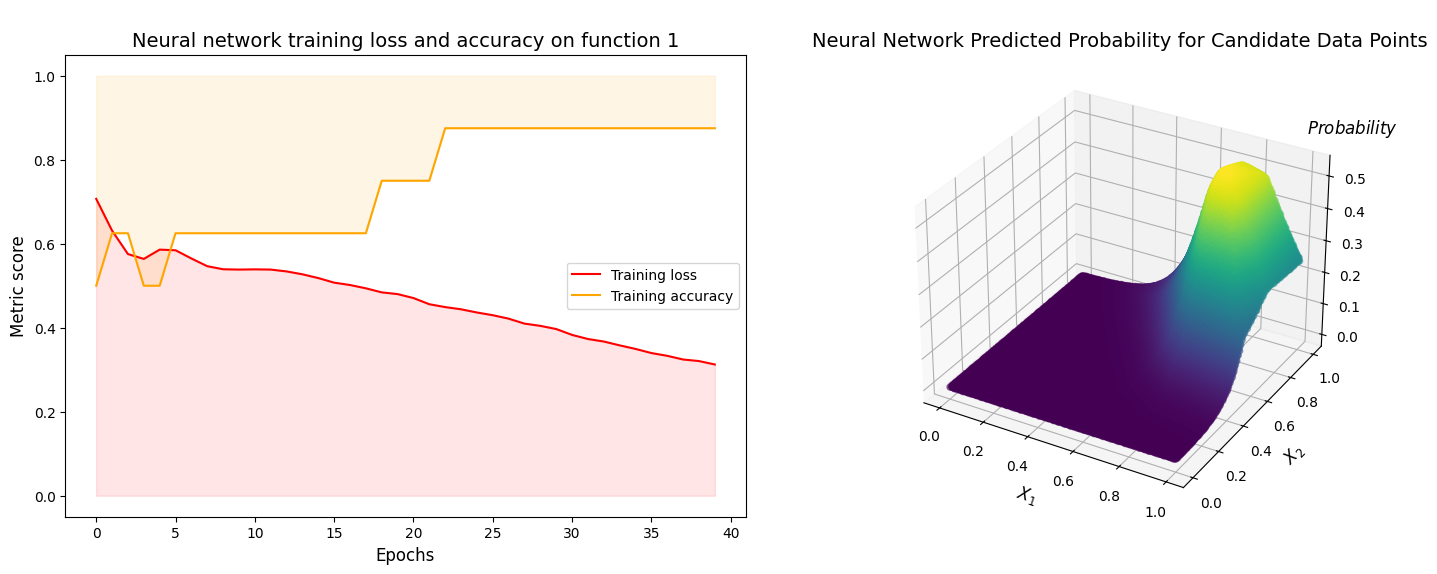

In [160]:
# ==== Creating neural network for function 1 ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Creating training tensors
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
X_tensor, y_tensor, y_class = training_tensors(X, y)

# Defining model architecture
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
input_dim = X.shape[1]
hidden_dim = len(X)

model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),       # Linear input layer
    nn.ReLU(),                              # ReLU activation
    nn.Linear(hidden_dim,hidden_dim),       # 2nd linear layer
    nn.ReLU(),                              # ReLU activation
    nn.Linear(hidden_dim,1),                # Linear output layer
    nn.Sigmoid()                            # Sigmoid activation - for binary classification    
)


# Defining model hyperparameters
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
criterion = nn.BCELoss()
optimiser = optim.Adam(model.parameters(), lr=0.04)
epochs = 40

# Running model through iterative cycle
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
model_nn, y_pred_nn, loss_history, accuracy_history = train_nn(X_tensor, y_tensor, y_class, model, epochs, criterion, optimiser)


# Creating X candidates and predicting
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
sampler = qmc.Sobol(2)
X_candidates = sampler.random(2**15)

with torch.no_grad(): # Disable gradients for faster computation
    X_candidates_tensor = torch.from_numpy(X_candidates).float()

    X_candidates_prob_tensor = model_nn(X_candidates_tensor)
    X_candidates_prob = X_candidates_prob_tensor.cpu().numpy().ravel()

# Plotting neural network performance
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
epochs_array = np.arange(0,epochs,1)
nn_combined_plots(epochs_array, loss_history, accuracy_history, X_candidates, X_candidates_prob, function=1)

#### Applying a GP surrogate model and acquisition function

The next query point is: [0.996249 0.944722]

Submission format:        0.996249-0.944722

The best y value observed so far is: 7.710875114502849e-16 at iteration 3, with inputs [0.73102363 0.73299988]


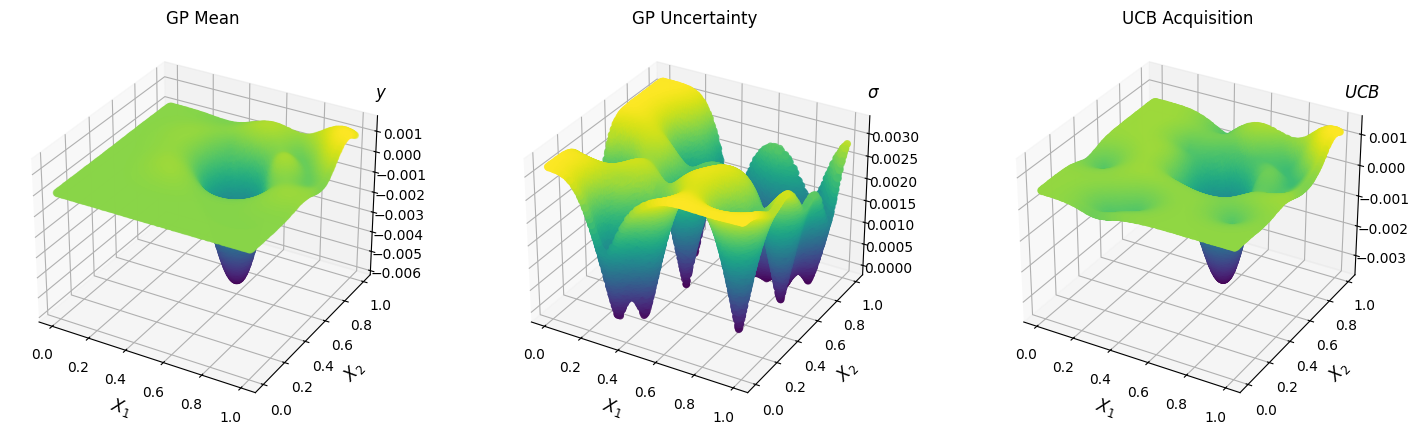

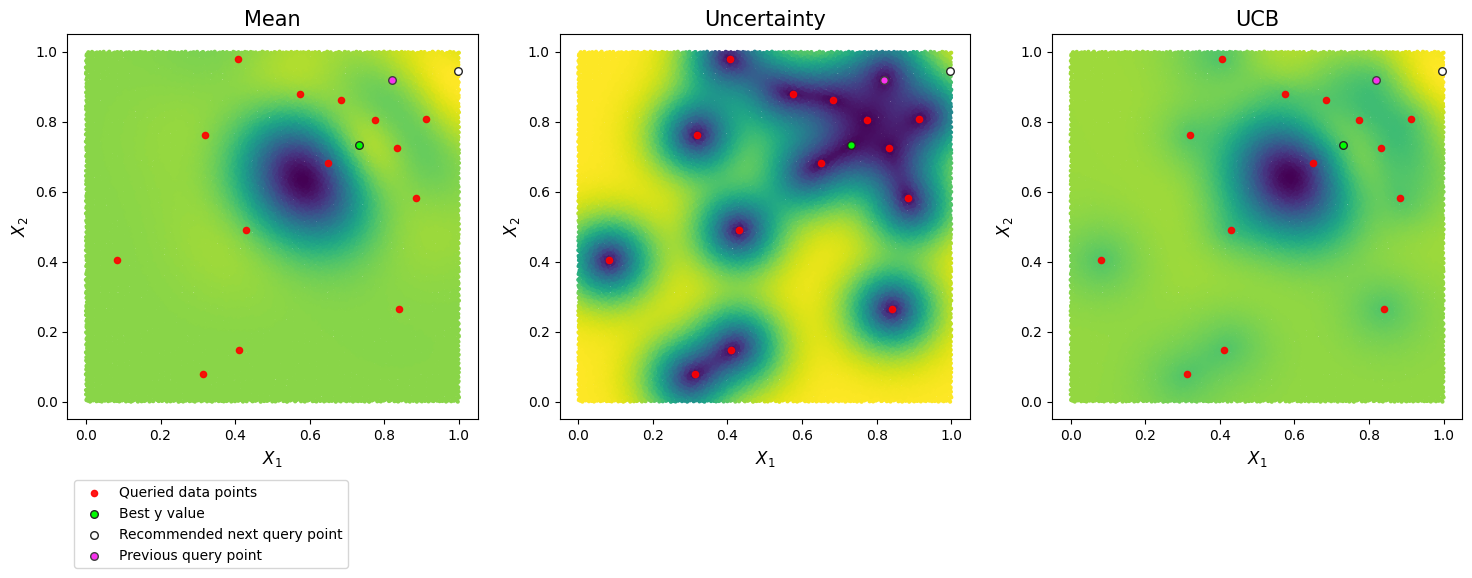

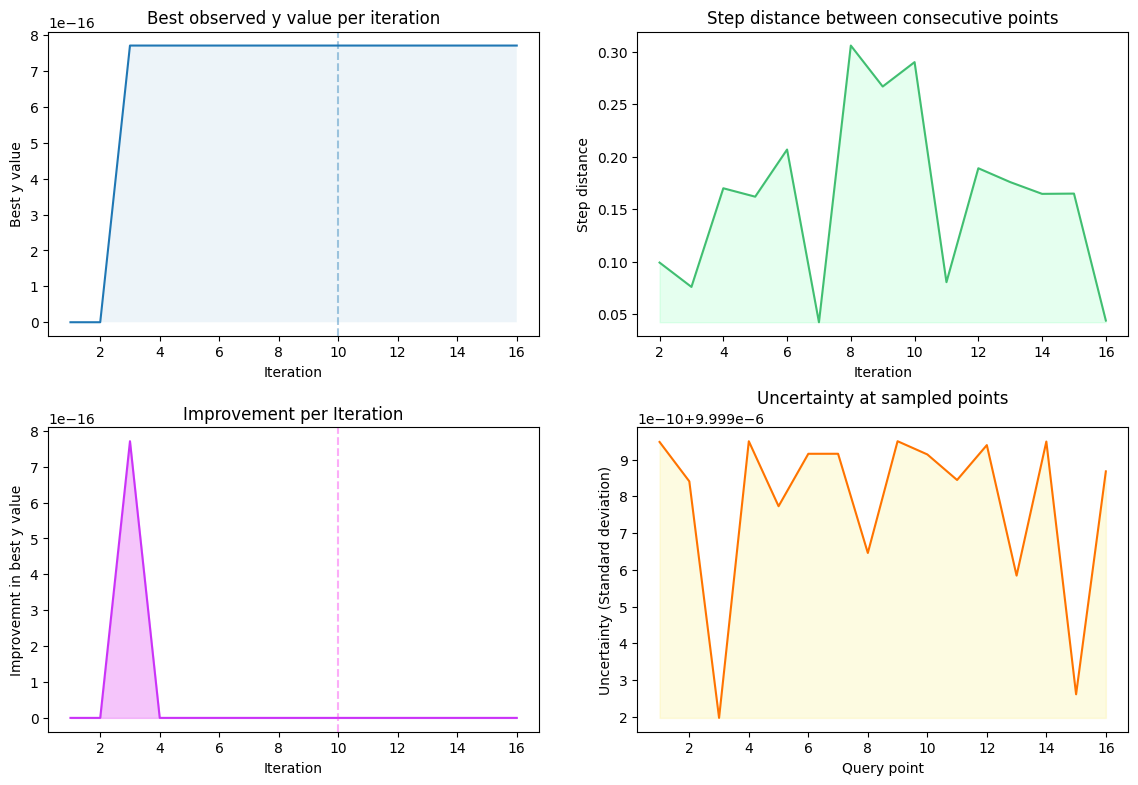

In [ ]:
# ==== Defining GP model and fitting to data ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
kernel = ConstantKernel(1.0) * RBF(length_scale=1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15) # Look at parameters, some are interesting like normalise y.
model = gpr.fit(X, y)

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)


# ==== Acquisition function ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
acquisition_function = 'UCB'

kappa = .3
best_value1 = np.max(y)

if acquisition_function == 'UCB':
    ucb = ucb_acquisition(mu, sigma, kappa)
    acquisition = nn_weighted_ucb(ucb, X_candidates_prob)

elif acquisition_function == 'EI':   
    ei = expected_improvement(mu, sigma, best_value1)
    acquisition = nn_weighted_ei(ei, X_candidates_prob)

# Pick next query point
x_next = X_candidates[np.argmax(acquisition)]
print('The next query point is:', np.round(x_next, 6))

# Submission format for next query point
submission = f"{x_next[0]:.6f}-{x_next[1]:.6f}"
print('\nSubmission format:       ', submission)

manual_search = None


# ==== Metrics ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
(best_value1_rolling, best_value1, best_value1_index, best_value1_inputs, 
improvement, step_dist, step_dist_normalised, step_dist_min) = performance_metrics(X, y)

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)


# ==== Visualising Results ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# 3D mesh plots
mesh_plots_new(X_candidates, mu, sigma, acquisition, acquisition_function)
# Contour plots
contour_plots_new(X, X_candidates, mu, sigma, acquisition, x_next, best_value1_inputs, acquisition_function, manual_search)
# Performance tracking plots
performance_plots(X, 10, best_value1_rolling, improvement, step_dist_normalised, step_dist, step_dist_min, sigma_selected)

## <ins>Function 2</ins>

**2-dimensional**

Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. 
To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

**Approach**:

Potentially multiple peaks, start with high kappa. RBF kernel.

### Importing data

In [154]:
function2_inputs = np.load(f'C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week {current_week}/Function 2/function2_inputs_week{current_week}.npy')
print('Inputs: \n', function2_inputs)

function2_outputs = np.load(f'C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week {current_week}/Function 2/function2_outputs_week{current_week}.npy')
print('Outputs: \n',function2_outputs)

X = function2_inputs
y = function2_outputs

print(len(X), len(y))

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1,1)).ravel()

Inputs: 
 [[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.21       0.8       ]
 [0.6        0.42      ]
 [0.800537   0.921613  ]
 [0.673479   0.928902  ]
 [0.68597    0.889318  ]
 [0.19       0.64      ]]
Outputs: 
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522 -0.03462578  0.02460055
  0.11093379  0.55312196  0.6022346   0.0511448 ]
16 16


### Creating neural network using nn.Sequential

Epoch: 0, Loss: 0.7129048109054565, Accuracy: 0.625
Epoch: 3, Loss: 0.5942652821540833, Accuracy: 0.5
Epoch: 6, Loss: 0.5772501230239868, Accuracy: 0.5
Epoch: 9, Loss: 0.5646702647209167, Accuracy: 0.5
Epoch: 12, Loss: 0.5447470545768738, Accuracy: 0.875


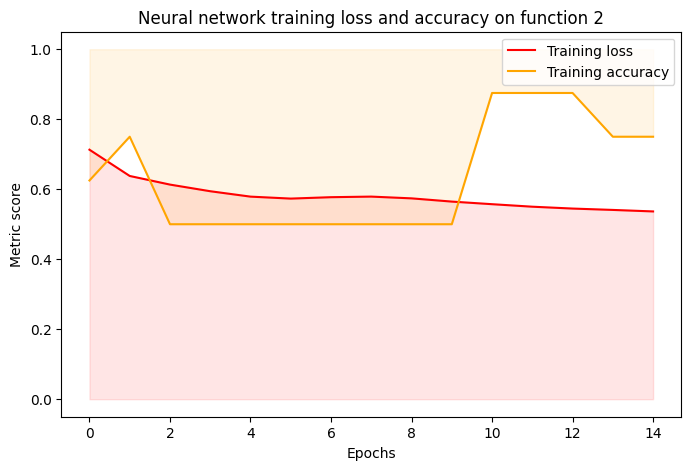

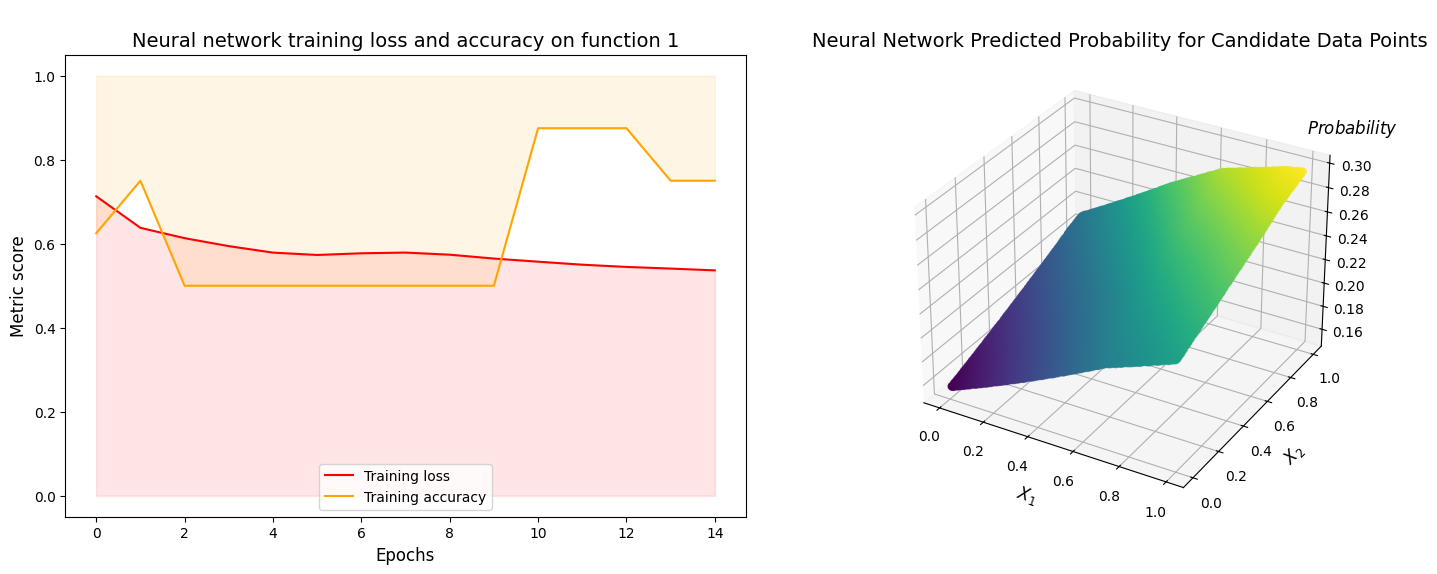

In [ ]:
# ==== Creating neural network for function 2 ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Creating training tensors
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
X_tensor, y_tensor, y_class = training_tensors(X, y)

# Defining model architecture
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
input_dim = X.shape[1]
hidden_dim = len(X)

model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),       # Linear input layer
    nn.ReLU(),                              # ReLU activation
    nn.Linear(hidden_dim,hidden_dim),       # 2nd linear layer
    nn.ReLU(),                              # ReLU activation
    nn.Linear(hidden_dim,1),                # Linear output layer
    nn.Sigmoid()                            # Sigmoid activation - for binary classification    
)


# Defining model hyperparameters
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
criterion = nn.BCELoss()
optimiser = optim.Adam(model.parameters(), lr=0.05)
epochs = 15

# Running model through iterative cycle
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
model_nn, y_pred_nn, loss_history, accuracy_history = train_nn(X_tensor, y_tensor, y_class, model, epochs, criterion, optimiser)


# Creating X candidates and predicting
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
sampler = qmc.Sobol(2)
X_candidates = sampler.random(2**15)

with torch.no_grad(): # Disable gradients for faster computation
    X_candidates_tensor = torch.from_numpy(X_candidates).float()

    X_candidates_prob_tensor = model_nn(X_candidates_tensor)
    X_candidates_prob = X_candidates_prob_tensor.cpu().numpy().ravel()

# Plotting neural network performance
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
epochs_array = np.arange(0,epochs,1)
nn_combined_plots(epochs_array, loss_history, accuracy_history, X_candidates, X_candidates_prob, function=2)


### Surrogate and Acquisition functions

The next query point is: [0.717563 0.88849 ]

Submission format:        0.717563-0.888490

The best y value observed so far is: 0.6112052157614438 at iteration 10, with inputs [0.70263656 0.9265642 ]


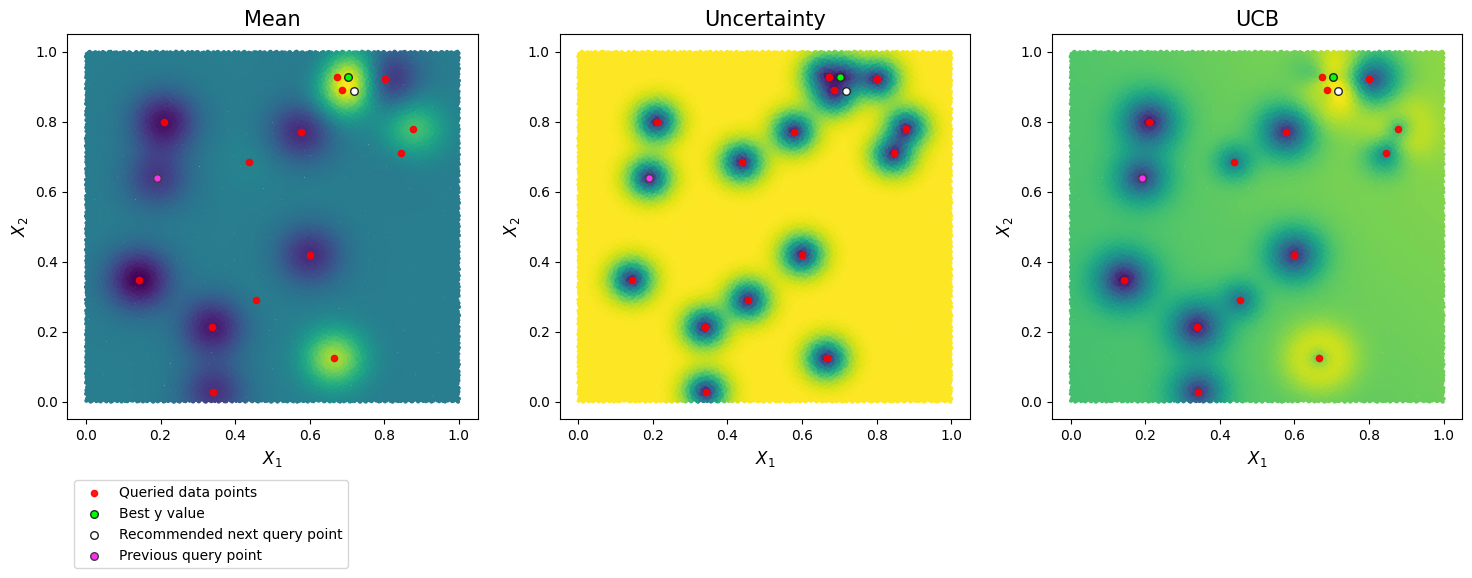

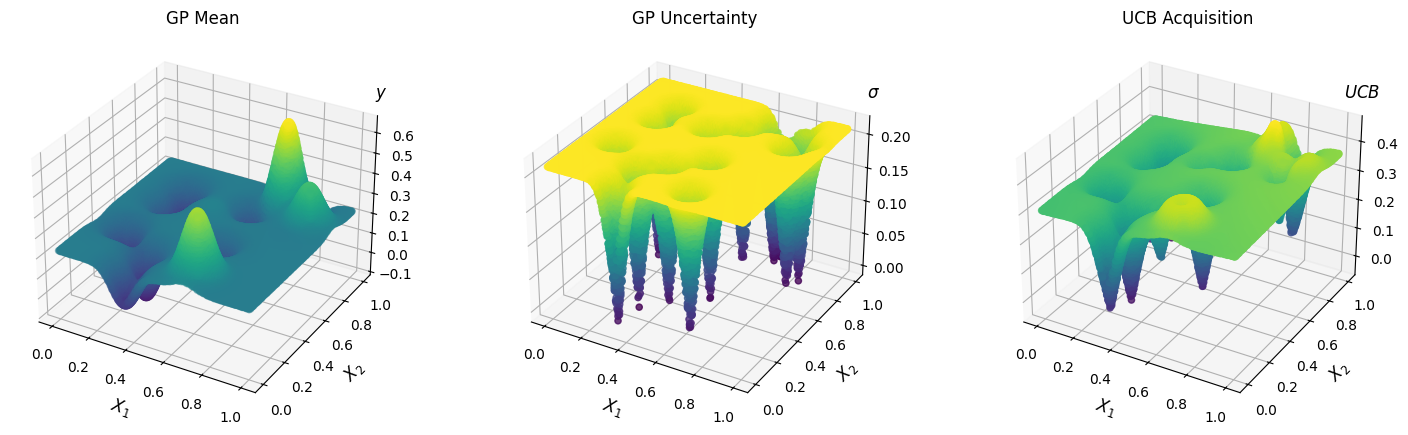

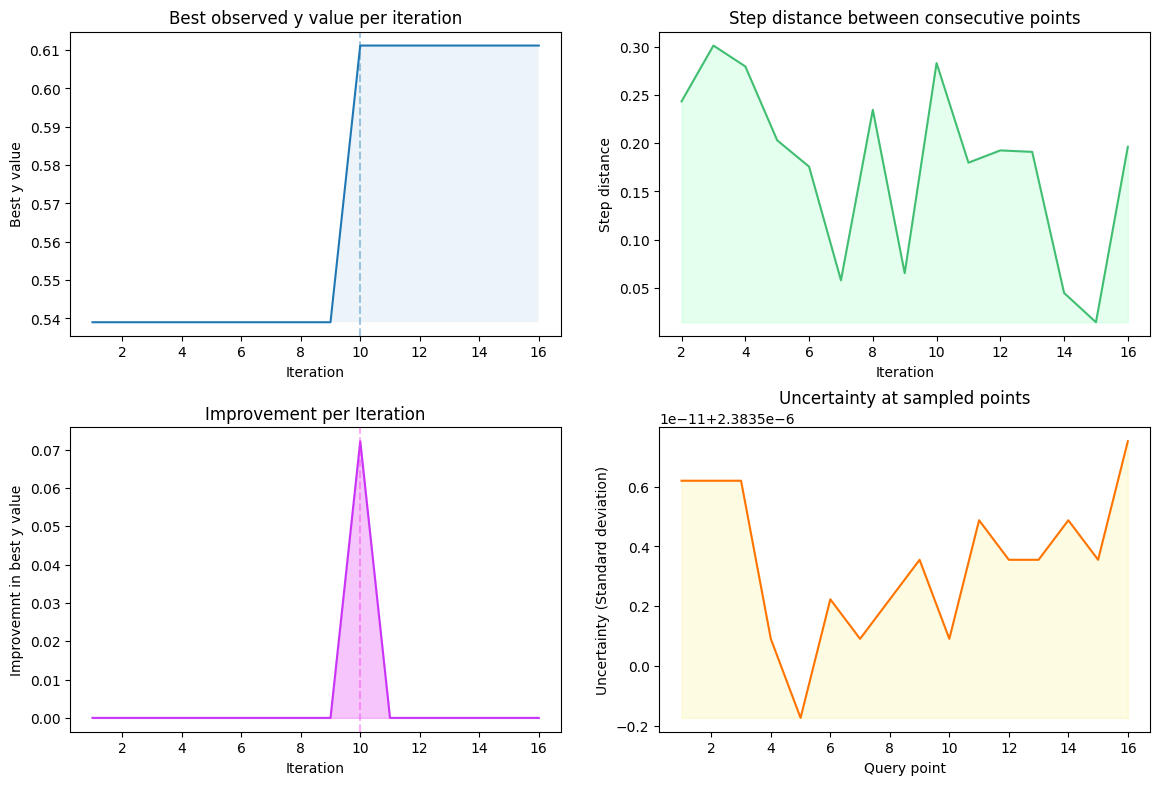

In [88]:
# Defining GP model and fitting to data
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

kernel = ConstantKernel(1.0) * RBF(length_scale=1) #Matern(nu=2.5) 
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15, normalize_y=True)
model = gpr.fit(X, y) # y_scaled

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function 
acquisition_function = 'UCB'

kappa = 1.5
best_value2_scaled = np.max(y)

if acquisition_function == 'UCB':
    ucb = ucb_acquisition(mu, sigma, kappa)
    acquisition = nn_weighted_ucb(ucb, X_candidates_prob)
elif acquisition_function == 'EI':   
    ei = expected_improvement(mu, sigma, best_value2_scaled)
    acquisition = nn_weighted_ei(ei, X_candidates_prob)


# Pick next point
x_next = X_candidates[np.argmax(acquisition)]
print('The next query point is:', np.round(x_next,6))

submission = f"{x_next[0]:.6f}-{x_next[1]:.6f}"
print('\nSubmission format:       ', submission)

manual_search = None


# ==== Metrics ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
(best_value2_rolling, best_value2, best_value1_index, best_value2_inputs, 
improvement, step_dist, step_dist_normalised, step_dist_min) = performance_metrics(X, y)

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)


# ==== Visualising Results ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Contour plots
contour_plots_new(X, X_candidates, mu, sigma, acquisition, x_next, best_value2_inputs, acquisition_function, manual_search)
# 3D mesh plots
mesh_plots_new(X_candidates, mu, sigma, acquisition, acquisition_function)
# Performance tracking plots
performance_plots(X, 10, best_value2_rolling, improvement, 
                      step_dist_normalised, step_dist, step_dist_min, sigma_selected)
plt.show()

## <ins>Function 3</ins>

**3-dimensional**

You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine.
Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array.
Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects). 

**Approach**:

Start with high kappa, RBF kernel.

In [111]:
function3_inputs = np.load(f'C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week {current_week}/Function 3/function3_inputs_week{current_week}.npy')
print('Inputs: \n', function3_inputs)

function3_outputs = np.load(f'C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week {current_week}/Function 3/function3_outputs_week{current_week}.npy')
print('Outputs: \n',function3_outputs)

X = function3_inputs
y = function3_outputs

print(len(X), len(y))

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1,1)).ravel()


Inputs: 
 [[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.21991724 0.45820622]
 [0.34552327 0.94135983 0.26936348]
 [0.15183663 0.43999062 0.99088187]
 [0.64550284 0.39714294 0.91977134]
 [0.74691195 0.28419631 0.22629985]
 [0.17047699 0.6970324  0.14916943]
 [0.22054934 0.29782524 0.34355534]
 [0.66601366 0.67198515 0.2462953 ]
 [0.04680895 0.23136024 0.77061759]
 [0.60009728 0.72513573 0.06608864]
 [0.96599485 0.86111969 0.56682913]
 [0.51764    0.004569   0.569925  ]
 [0.891717   0.852251   0.371034  ]
 [0.414483   0.061504   0.530133  ]
 [0.430025   0.43138    0.511326  ]
 [0.5048     0.719751   0.254471  ]
 [0.389175   0.476462   0.41083   ]]
Outputs: 
 [-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -0.11386851 -0.13146061 -0.09418956 -0.04694741 -0.10596504
 -0.11804826 -0.03637783 -0.05675837 -0.09884205 -0.06638201 -0.08545748
 -0

### Creating neural network using nn.Sequential

Epoch: 0, Loss: 0.6377761960029602, Accuracy: 0.5238095238095238
Epoch: 7, Loss: 0.5495795011520386, Accuracy: 0.7142857142857143
Epoch: 14, Loss: 0.5230486989021301, Accuracy: 0.7142857142857143
Epoch: 21, Loss: 0.5023987889289856, Accuracy: 0.6190476190476191
Epoch: 28, Loss: 0.4713699221611023, Accuracy: 0.7142857142857143
Epoch: 35, Loss: 0.42069166898727417, Accuracy: 0.8095238095238095
Epoch: 42, Loss: 0.35221245884895325, Accuracy: 0.9047619047619048
Epoch: 49, Loss: 0.2838785648345947, Accuracy: 1.0
Epoch: 56, Loss: 0.23333385586738586, Accuracy: 1.0
Epoch: 63, Loss: 0.18767282366752625, Accuracy: 1.0


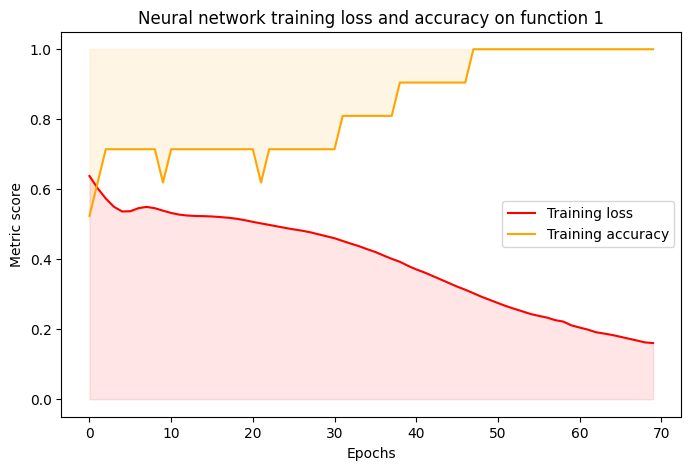

In [114]:
# ==== Creating neural network for function 3 ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Creating training tensors
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
X_tensor, y_tensor, y_class = training_tensors(X, y)

# Defining model architecture
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
input_dim = X.shape[1]
hidden_dim = len(X)

model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),       # Linear input layer
    nn.ReLU(),                      # ReLU activation
    nn.Linear(hidden_dim, hidden_dim),               # 2nd linear layer
    nn.ReLU(),                      # ReLU activation
    nn.Linear(hidden_dim, 1),                # Linear output layer
    nn.Sigmoid()                    # Sigmoid activation - for binary classification    
)


# Defining model hyperparameters
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
criterion = nn.BCELoss()
optimiser = optim.Adam(model.parameters(), lr=0.02)
epochs = 70

# Running model through iterative cycle
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
model, y_pred_nn, loss_history, accuracy_history = train_nn(X_tensor, y_tensor, y_class, model, epochs, criterion, optimiser)

# Creating X candidates and predicting
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
sampler = qmc.Sobol(3)
X_candidates = sampler.random(2**15)

with torch.no_grad(): # Disable gradients for faster computation
    X_candidates_tensor = torch.from_numpy(X_candidates).float()

    X_candidates_prob_tensor = model(X_candidates_tensor)
    #X_candidates_prob = X_candidates_prob_tensor.detach().numpy()
    X_candidates_prob = X_candidates_prob_tensor.cpu().numpy().ravel()

# Plotting neural network performance
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
epochs_array = np.arange(0,epochs,1)
plot_nn(epochs_array, loss_history, accuracy_history, 1)


The next query point is: [0.425264 0.542815 0.492566]

Submission format:        0.425264-0.542815-0.492566

The best y value observed so far is: -0.006048470333684279 at iteration 21, with inputs [0.389175 0.476462 0.41083 ]


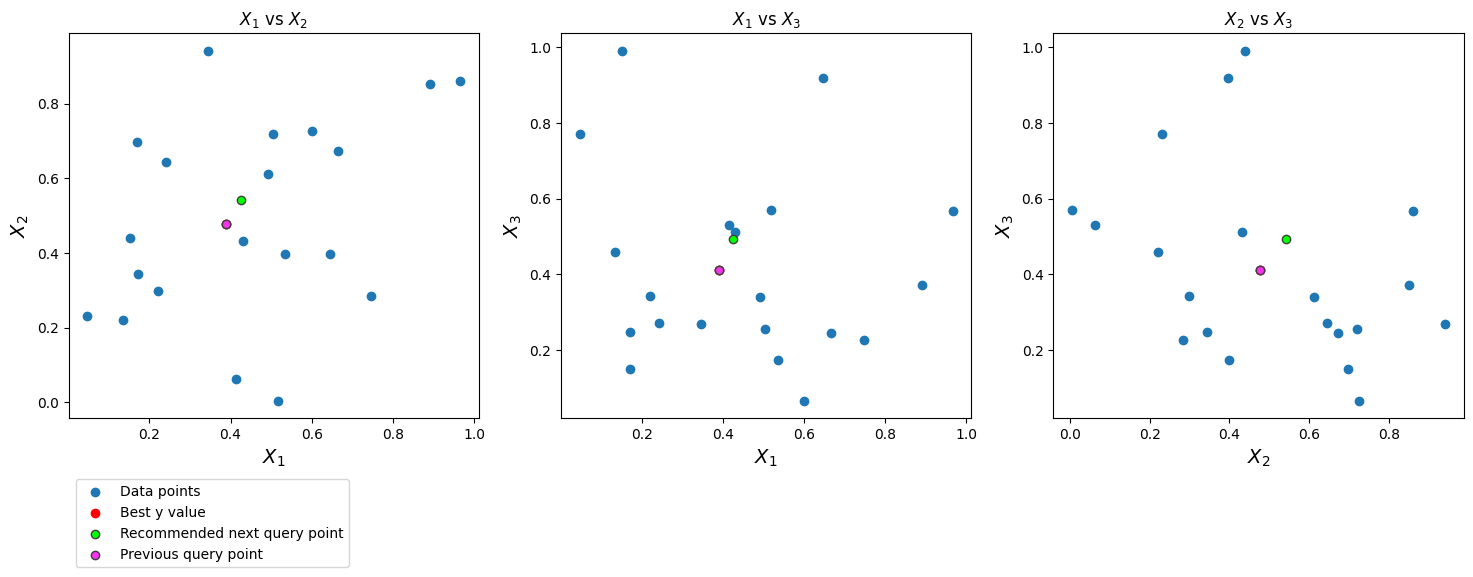

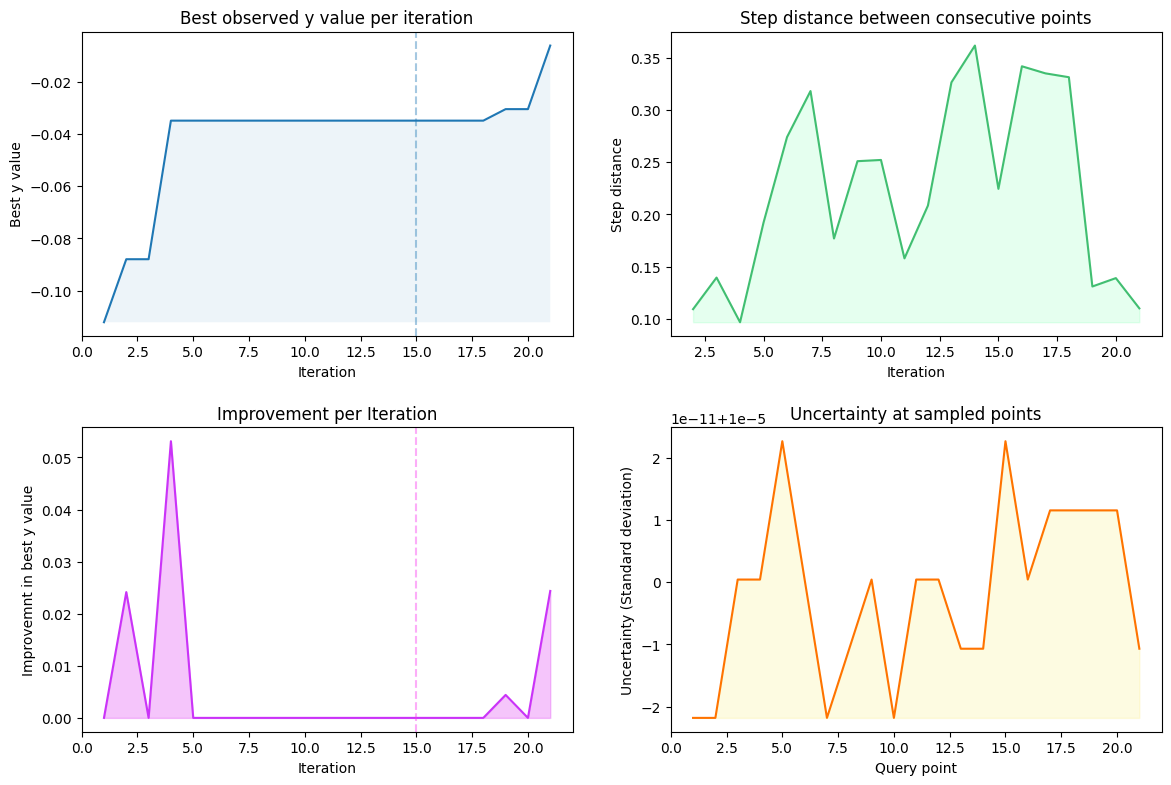

In [116]:
# Defining GP model and fitting to data
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

kernel = ConstantKernel(1.0) * RBF(length_scale=1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9) # Look at parameters, some are interesting like normalise y.
model = gpr.fit(X, y_scaled)

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 1.5
acquisition_function = (mu + kappa * sigma) * (0.5 + 0.5 * X_candidates_prob)

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]
print('The next query point is:', np.round(x_next,6))

submission = f"{x_next[0]:.6f}-{x_next[1]:.6f}-{x_next[2]:.6f}"
print('\nSubmission format:       ', submission)


# ==== Metrics ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
(best_value3_rolling, best_value3, best_value3_index, best_value3_inputs, 
improvement, step_dist, step_dist_normalised, step_dist_min) = performance_metrics(X, y)

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)


# ==== Visualisation ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Pair scatter plots
scatter_plot_pairs = np.array([[1,2],   # X1 vs X2
                               [1,3],   # X1 vs X3
                               [2,3]])  # X2 vs X3
scatter_plots(scatter_plot_pairs, X, x_next, best_value3_inputs, manual_search=None)

# Performance tracking plots
performance_plots(X, 15, best_value3_rolling, improvement, 
                      step_dist_normalised, step_dist, step_dist_min, sigma_selected)

plt.show()

## <ins>Function 4</ins>

**4-dimensional**

Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly. To speed up decision-making, an ML model approximates these results within hours. The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions.

**Approach**:

Many maxima - start with high kappa and slower decay, add random exploration.
Kernel - Matern(v=1.5 or 2.5) since the function is less smooth.

In [107]:
function4_inputs = np.load(f'C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week {current_week}/Function 4/function4_inputs_week{current_week}.npy')
print('Inputs: \n', function4_inputs)

function4_outputs = np.load(f'C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week {current_week}/Function 4/function4_outputs_week{current_week}.npy')
print('Outputs: \n',function4_outputs)

X = function4_inputs
y = function4_outputs

print(len(X), len(y))

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1,1)).ravel()

Inputs: 
 [[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.99948256]
 [0

### Creating neural network using nn.Sequential

Epoch: 0, Loss: 0.6592360138893127, Accuracy: 0.6111111111111112
Epoch: 4, Loss: 0.5456462502479553, Accuracy: 0.6666666666666666
Epoch: 8, Loss: 0.4989410638809204, Accuracy: 0.6666666666666666
Epoch: 12, Loss: 0.489825576543808, Accuracy: 0.6666666666666666
Epoch: 16, Loss: 0.4727395474910736, Accuracy: 0.6666666666666666
Epoch: 20, Loss: 0.43872514367103577, Accuracy: 0.6666666666666666
Epoch: 24, Loss: 0.3984886407852173, Accuracy: 0.8333333333333334
Epoch: 28, Loss: 0.3441305160522461, Accuracy: 0.8888888888888888
Epoch: 32, Loss: 0.28947266936302185, Accuracy: 0.8888888888888888
Epoch: 36, Loss: 0.2382761687040329, Accuracy: 0.9444444444444444


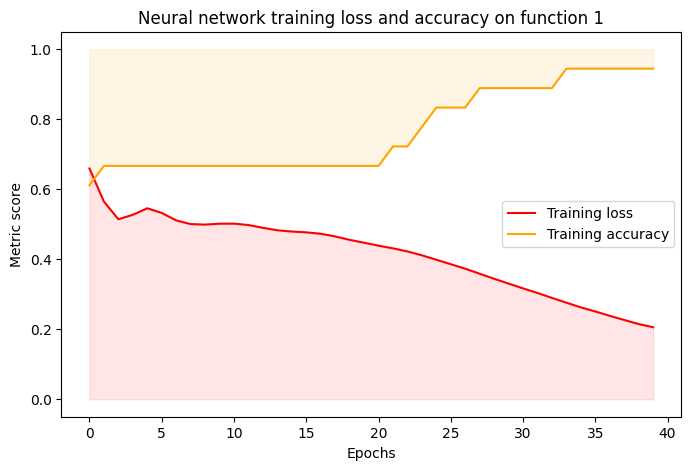

In [108]:
# ==== Creating neural network for function 4 ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Creating training tensors
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
X_tensor, y_tensor, y_class = training_tensors(X, y)

# Defining model architecture
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
input_dim = X.shape[1]
hidden_dim = len(X)

model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),       # Linear input layer
    nn.ReLU(),                      # ReLU activation
    nn.Linear(hidden_dim, hidden_dim),               # 2nd linear layer
    nn.ReLU(),                      # ReLU activation
    nn.Linear(hidden_dim, 1),                # Linear output layer
    nn.Sigmoid()                    # Sigmoid activation - for binary classification    
)


# Defining model hyperparameters
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
criterion = nn.BCELoss()
optimiser = optim.Adam(model.parameters(), lr=0.02)
epochs = 40

# Running model through iterative cycle
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
model, y_pred_nn, loss_history, accuracy_history = train_nn(X_tensor, y_tensor, y_class, model, epochs, criterion, optimiser)


# Creating X candidates and predicting
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
# Smart search, scales much better in higher dimensions.
sampler = qmc.Sobol(4)
X_candidates = sampler.random(2**15)

with torch.no_grad(): # Disable gradients for faster computation
    X_candidates_tensor = torch.from_numpy(X_candidates).float()

    X_candidates_prob_tensor = model(X_candidates_tensor)
    #X_candidates_prob = X_candidates_prob_tensor.detach().numpy()
    X_candidates_prob = X_candidates_prob_tensor.cpu().numpy().ravel()

# Plotting neural network performance
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
epochs_array = np.arange(0,epochs,1)
plot_nn(epochs_array, loss_history, accuracy_history, 1)

The next query point is: [0.451159 0.342943 0.418854 0.432385]

Submission format:        0.451159-0.342943-0.418854-0.432385

The best y value observed so far is: 0.11560165275106771 at iteration 33, with inputs [0.423825 0.446901 0.400751 0.401047]


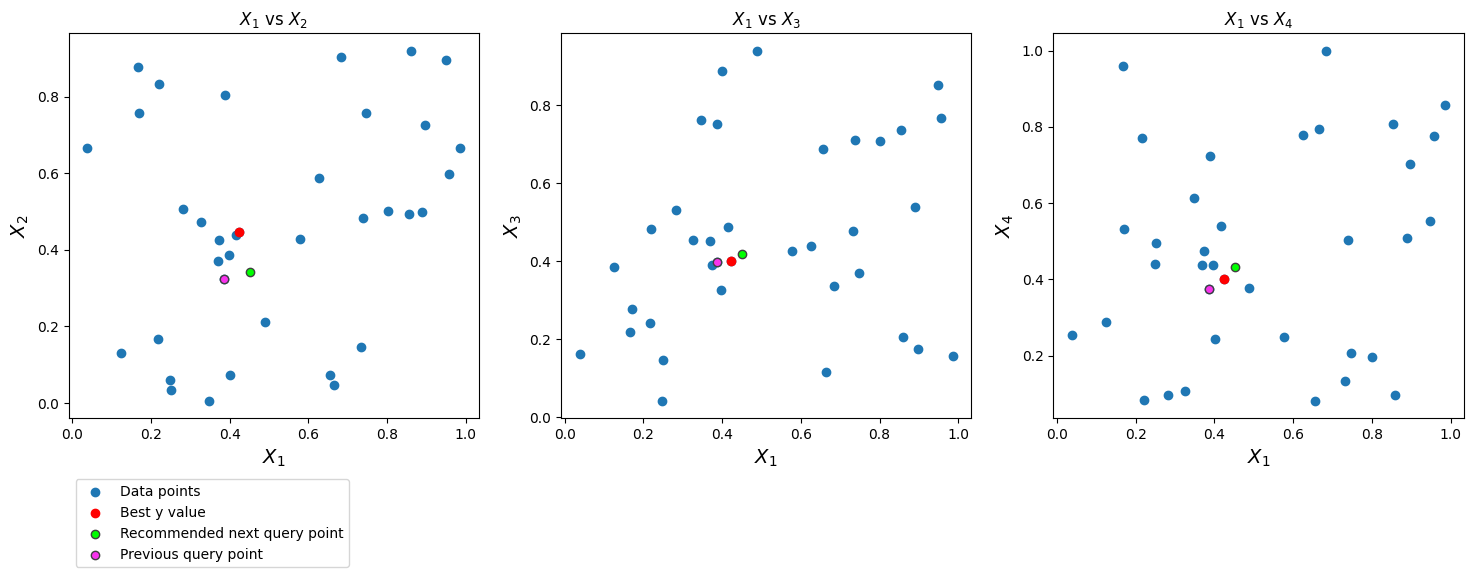

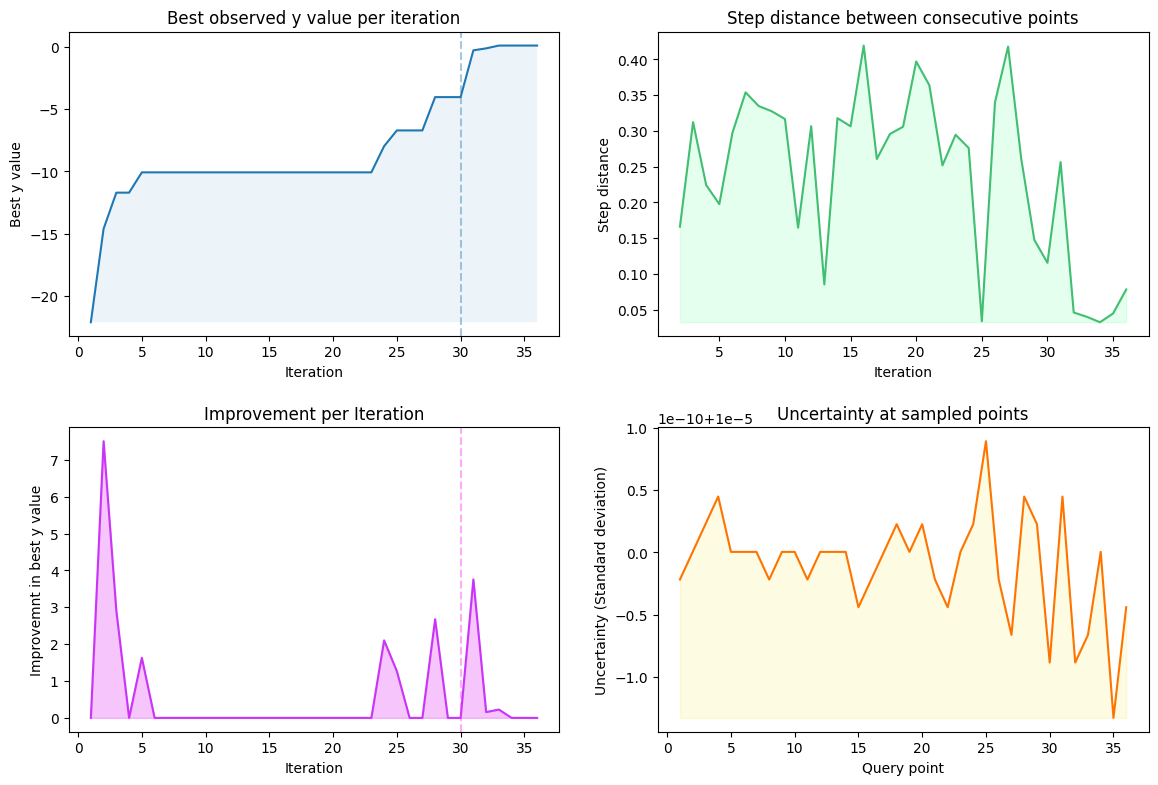

In [110]:
# Defining GP model and fitting to data
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
kernel = ConstantKernel(1.0) * Matern(length_scale=1, nu=2.5)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9) # Look at parameters, some are interesting like normalise y.
model = gpr.fit(X, y_scaled)

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 1.5
acquisition_function = (mu + kappa * sigma) * (0.5 + 0.5 * X_candidates_prob) 

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]
print('The next query point is:', np.round(x_next,6))

submission = f"{x_next[0]:.6f}-{x_next[1]:.6f}-{x_next[2]:.6f}-{x_next[3]:.6f}"
print('\nSubmission format:       ', submission)


# ==== Metrics ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

(best_value4_rolling, best_value4, best_value4_index, best_value4_inputs, 
improvement, step_dist, step_dist_normalised, step_dist_min) = performance_metrics(X, y)

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)


# ==== Visualisation ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Pair scatter plots
scatter_plot_pairs = np.array([[1,2],   # X1 vs X2
                               [1,3],   # X1 vs X3
                               [1,4]])  # X1 vs X4
scatter_plots(scatter_plot_pairs, X, x_next, best_value4_inputs, manual_search=None)

# Performance tracking plots
performance_plots(X, 30, best_value4_rolling, improvement, 
                      step_dist_normalised, step_dist, step_dist_min, sigma_selected)

plt.show()

## <ins>Function 5</ins>

**4-dimensional**

You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. 
Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

**Approach**:

Unimodal, so start with low kappa, potentially switch to EI early. RBF kernel.

In [87]:
function5_inputs = np.load(f'C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week {current_week}/Function 5/function5_inputs_week{current_week}.npy')
print('Inputs: \n', function5_inputs)

function5_outputs = np.load(f'C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week {current_week}/Function 5/function5_outputs_week{current_week}.npy')
print('Outputs: \n',function5_outputs)

X = function5_inputs
y = function5_outputs

print(len(X), len(y))

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1,1)).ravel()

Inputs: 
 [[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.39689    0.353366   0.237596   0.128478  ]
 [0

### Creating neural network using nn.Sequential

Epoch: 0, Loss: 0.6944036483764648, Accuracy: 0.5384615384615384
Epoch: 1, Loss: 0.6347544193267822, Accuracy: 0.5384615384615384
Epoch: 2, Loss: 0.5926492214202881, Accuracy: 0.5384615384615384
Epoch: 3, Loss: 0.5657307505607605, Accuracy: 0.5384615384615384
Epoch: 4, Loss: 0.5445566773414612, Accuracy: 0.5384615384615384
Epoch: 5, Loss: 0.5165238976478577, Accuracy: 0.6153846153846154
Epoch: 6, Loss: 0.48263734579086304, Accuracy: 0.8461538461538461
Epoch: 7, Loss: 0.44450318813323975, Accuracy: 0.9230769230769231
Epoch: 8, Loss: 0.40594053268432617, Accuracy: 1.0
Epoch: 9, Loss: 0.37109631299972534, Accuracy: 1.0


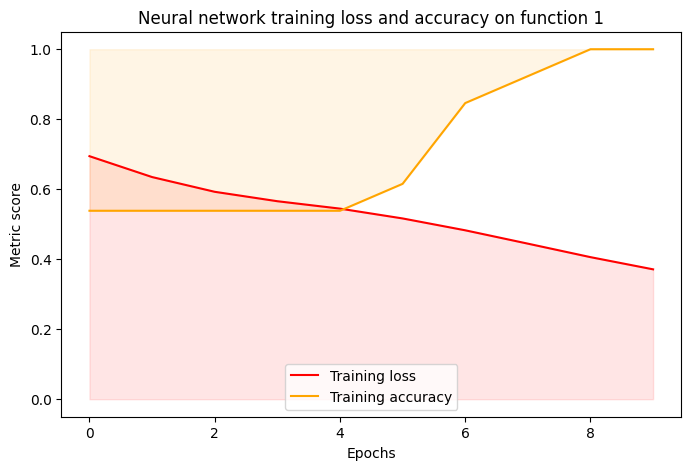

In [105]:
# ==== Creating neural network for function 5 ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Creating training tensors
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
X_tensor, y_tensor, y_class = training_tensors(X, y)

# Defining model architecture
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
input_dim = X.shape[1]
hidden_dim = len(X)

model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),   # Linear input layer
    nn.ReLU(),                          # ReLU activation
    nn.Linear(hidden_dim, hidden_dim),  # 2nd linear layer
    nn.ReLU(),                          # ReLU activation
    nn.Linear(hidden_dim, 1),           # Linear output layer
    nn.Sigmoid()                        # Sigmoid activation - for binary classification    
)


# Defining model hyperparameters
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
criterion = nn.BCELoss()
optimiser = optim.Adam(model.parameters(), lr=0.02)
epochs = 10

# Running model through iterative cycle
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
model, y_pred_nn, loss_history, accuracy_history = train_nn(X_tensor, y_tensor, y_class, model, epochs, criterion, optimiser)

# Creating X candidates and predicting
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
sampler = qmc.Sobol(4) # Using smarter sampling
X_candidates = sampler.random(2**15)

with torch.no_grad(): # Disable gradients for faster computation
    X_candidates_tensor = torch.from_numpy(X_candidates).float()

    X_candidates_prob_tensor = model(X_candidates_tensor)
    #X_candidates_prob = X_candidates_prob_tensor.detach().numpy()
    X_candidates_prob = X_candidates_prob_tensor.cpu().numpy().ravel()

# Plotting neural network performance
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
epochs_array = np.arange(0,epochs,1)
plot_nn(epochs_array, loss_history, accuracy_history, 1)


The next query point is: [0.370764 0.981545 0.999879 0.98486 ]

Submission format:        0.370764-0.981545-0.999879-0.984860

The best y value observed so far is: 3674.1691714862864 at iteration 25, with inputs [0.395419 0.993554 0.943592 0.993487]


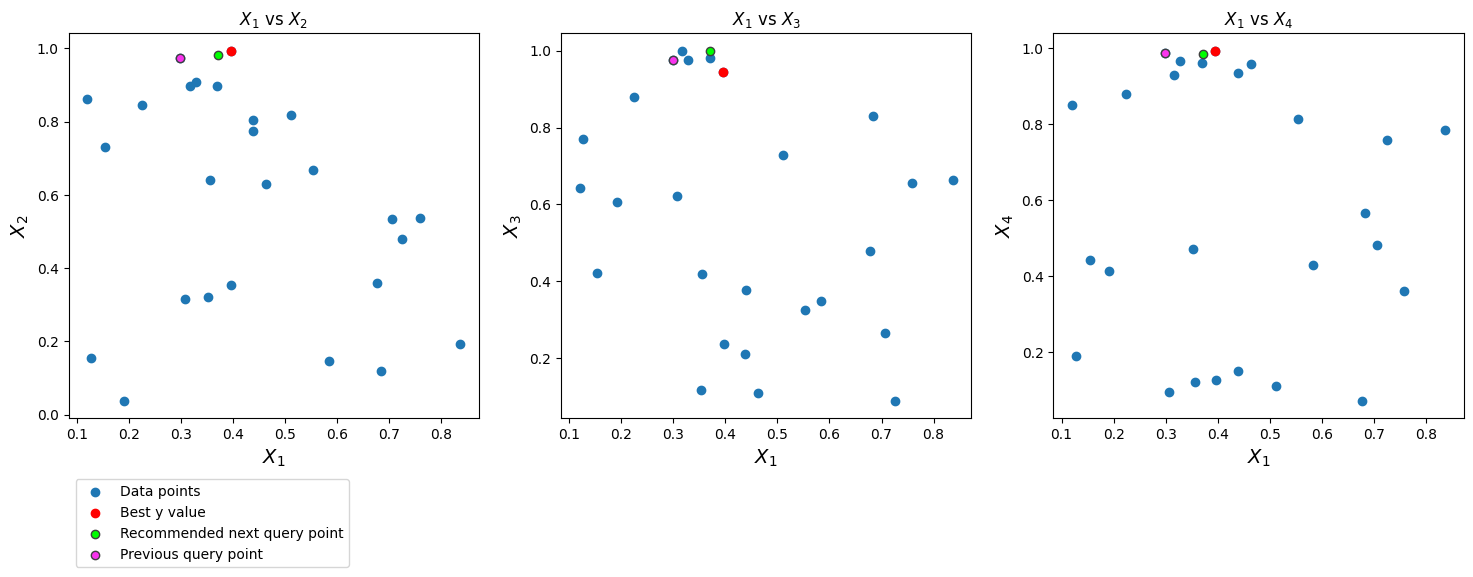

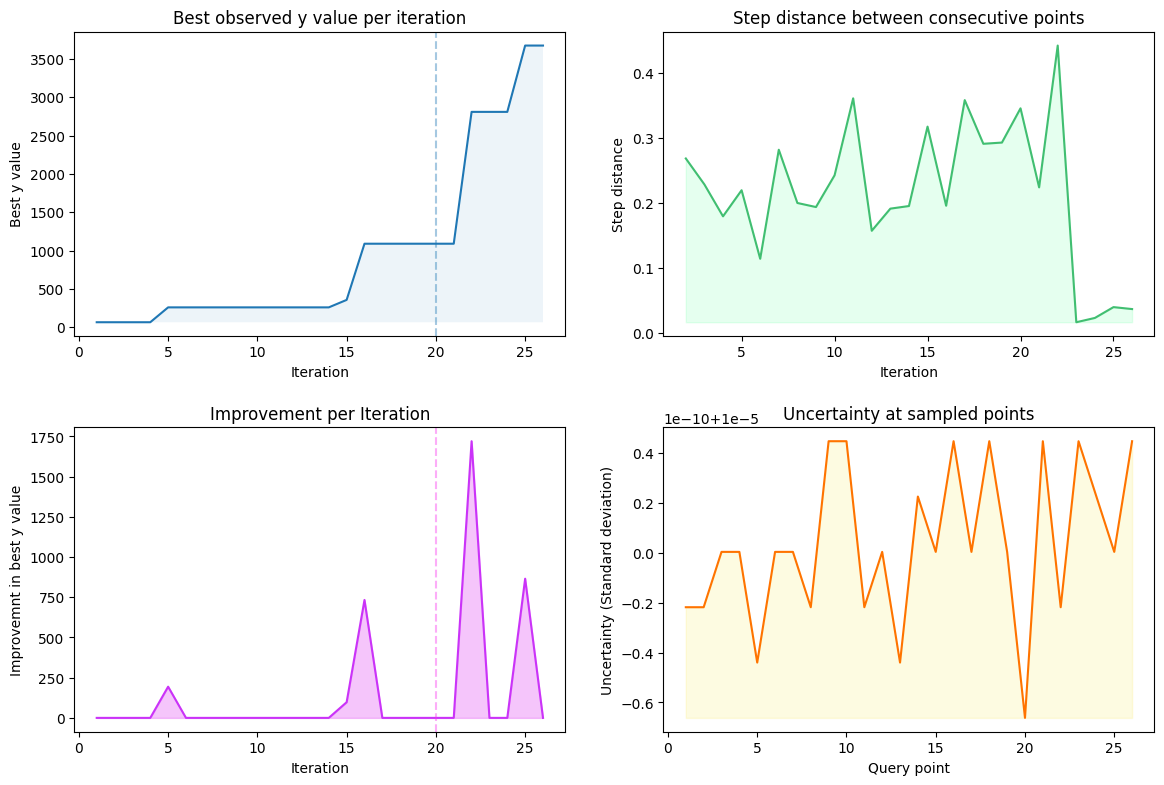

In [106]:
# Defining GP model and fitting to data
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
kernel = ConstantKernel(1.0) * RBF(length_scale=1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=12) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y_scaled)

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# ==== Acquisition function ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

acquisition_function = 'EI'

kappa = 1.5
y_best5_scaled = np.max(y_scaled)

if acquisition_function == 'UCB':
    ucb = ucb_acquisition(mu, sigma, kappa)
    acquisition = nn_weighted_ucb(ucb, X_candidates_prob)

elif acquisition_function == 'EI':   
    ei = expected_improvement(mu, sigma, y_best5_scaled)
    acquisition = nn_weighted_ei(ei, X_candidates_prob)

# Pick next point
x_next = X_candidates[np.argmax(acquisition)]
print('The next query point is:', np.round(x_next,6))

submission = f"{x_next[0]:.6f}-{x_next[1]:.6f}-{x_next[2]:.6f}-{x_next[3]:.6f}"
print('\nSubmission format:       ', submission)

# ==== Metrics ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
(best_value5_rolling, best_value5, best_value5_index, best_value5_inputs, 
improvement, step_dist, step_dist_normalised, step_dist_min) = performance_metrics(X, y)

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)


# ==== Visualisation ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Pair scatter plots
scatter_plot_pairs = np.array([[1,2],   # X1 vs X2
                               [1,3],   # X1 vs X3
                               [1,4]])  # X1 vs X4
scatter_plots(scatter_plot_pairs, X, x_next, best_value5_inputs, manual_search=None)

# Performance tracking plots
performance_plots(X, 20, best_value5_rolling, improvement, 
                      step_dist_normalised, step_dist, step_dist_min, sigma_selected)

plt.show()

## <ins>Function 6</ins>

**5-dimensional**

You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design. 
To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sum.

**Approach**:

Start with high kappa. RBF kernel.

In [84]:
function6_inputs = np.load(f'C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week {current_week}/Function 6/function6_inputs_week{current_week}.npy')
print('Inputs: \n', function6_inputs)

function6_outputs = np.load(f'C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week {current_week}/Function 6/function6_outputs_week{current_week}.npy')
print('Outputs: \n',function6_outputs)

X = function6_inputs
y = function6_outputs

print(len(X), len(y))

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1,1)).ravel()

Inputs: 
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.61496184]
 [0.

### Creating neural network using nn.Sequential

Epoch: 0, Loss: 0.7499452233314514, Accuracy: 0.5384615384615384
Epoch: 3, Loss: 0.56259685754776, Accuracy: 0.6153846153846154
Epoch: 6, Loss: 0.5465855002403259, Accuracy: 0.6923076923076923
Epoch: 9, Loss: 0.4982151389122009, Accuracy: 0.6923076923076923
Epoch: 12, Loss: 0.4584932029247284, Accuracy: 0.9230769230769231
Epoch: 15, Loss: 0.41997382044792175, Accuracy: 0.9230769230769231
Epoch: 18, Loss: 0.376115620136261, Accuracy: 0.9230769230769231
Epoch: 21, Loss: 0.3303561508655548, Accuracy: 0.9230769230769231
Epoch: 24, Loss: 0.2976006865501404, Accuracy: 0.9230769230769231
Epoch: 27, Loss: 0.26826179027557373, Accuracy: 0.9230769230769231


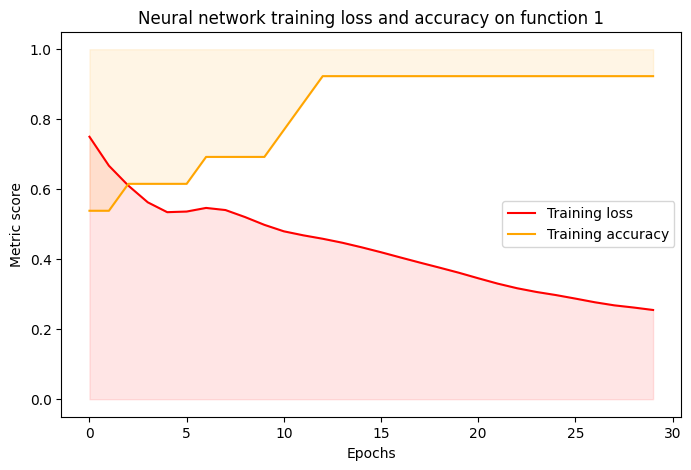

In [85]:
# ==== Creating neural network for function 6 ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Creating training tensors
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
X_tensor, y_tensor, y_class = training_tensors(X, y)

# Defining model architecture
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
input_dim = X.shape[1]
hidden_dim = len(X)

model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),   # Linear input layer
    nn.ReLU(),                          # ReLU activation
    nn.Linear(hidden_dim, hidden_dim),  # 2nd linear layer
    nn.ReLU(),                          # ReLU activation
    nn.Linear(hidden_dim, 1),           # Linear output layer
    nn.Sigmoid()                        # Sigmoid activation - for binary classification    
)


# Defining model hyperparameters
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
criterion = nn.BCELoss()
optimiser = optim.Adam(model.parameters(), lr=0.02)
epochs = 30

# Running model through iterative cycle
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
model, y_pred_nn, loss_history, accuracy_history = train_nn(X_tensor, y_tensor, y_class, model, epochs, criterion, optimiser)


# Creating X candidates and predicting
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

sampler = qmc.Sobol(5) # Using smarter sampling
X_candidates = sampler.random(2**15)

with torch.no_grad(): # Disable gradients for faster computation
    X_candidates_tensor = torch.from_numpy(X_candidates).float()

    X_candidates_prob_tensor = model(X_candidates_tensor)
    X_candidates_prob = X_candidates_prob_tensor.cpu().numpy().ravel()

# Plotting neural network performance
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
epochs_array = np.arange(0,epochs,1)
plot_nn(epochs_array, loss_history, accuracy_history, 1)


The next query point is: [0.399365 0.409818 0.553734 0.826048 0.063846]

Submission format:        0.399365-0.409818-0.553734-0.826048-0.063846

The best y value observed so far is: -0.2967920323841292 at iteration 23, with inputs [0.399104 0.391975 0.509423 0.706247 0.148625]


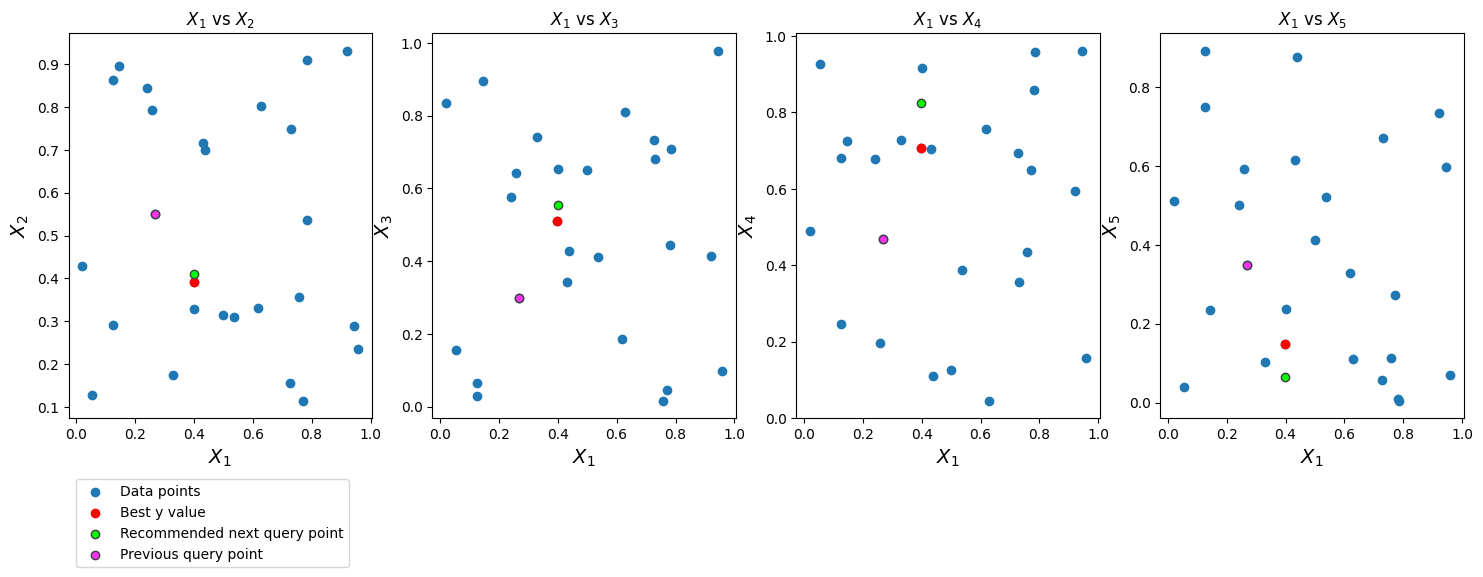

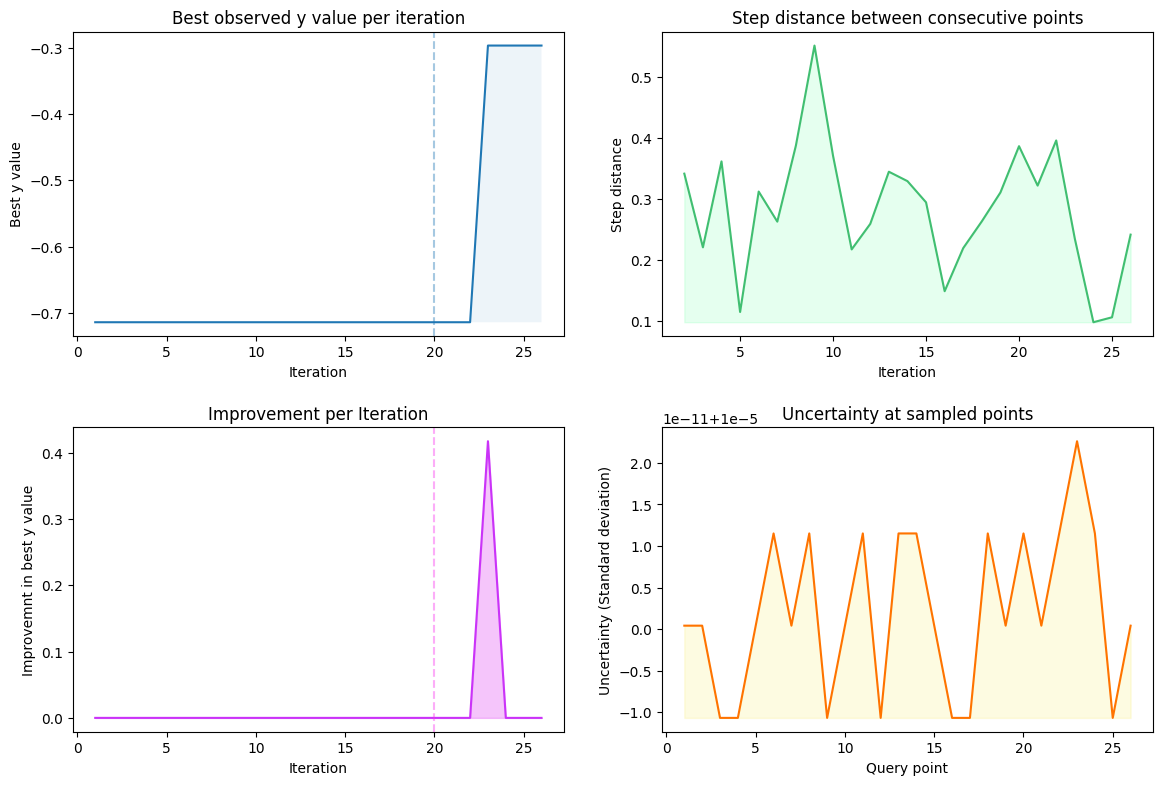

In [86]:
# Defining GP model and fitting to data
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

kernel = ConstantKernel(1.0) * RBF(length_scale=1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y_scaled)

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 1
acquisition_function = (mu + kappa * sigma) * (0.5 + 0.5 * X_candidates_prob) 

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]
print('The next query point is:', np.round(x_next,6))

submission = f"{x_next[0]:.6f}-{x_next[1]:.6f}-{x_next[2]:.6f}-{x_next[3]:.6f}-{x_next[4]:.6f}"
print('\nSubmission format:       ', submission)


# ==== Metrics ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

(best_value6_rolling, best_value6, best_value6_index, best_value6_inputs, 
improvement, step_dist, step_dist_normalised, step_dist_min) = performance_metrics(X, y)

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)


# ==== Visualisation ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Pair scatter plots
manual_search = [0.27, 0.55, 0.3, 0.47, 0.35]

scatter_plot_pairs = np.array([[1,2],   # X1 vs X2
                               [1,3],   # X1 vs X3
                               [1,4],   # X1 vs X4
                               [1,5]])  # X1 vs X5
scatter_plots(scatter_plot_pairs, X, x_next, best_value6_inputs, manual_search=None)

# Performance tracking plots
performance_plots(X, 20, best_value6_rolling, improvement, 
                      step_dist_normalised, step_dist, step_dist_min, sigma_selected)

plt.show()

## <ins>Function 7</ins>

**6-dimensional**

You’re tasked with optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you’re maximising is the model’s performance score (such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function. 
Because this is a commonly used model, you might benefit from researching best practices or literature to guide your initial search space. Your goal is to find the combination of hyperparameters that yields the highest possible performance.

**Approach**:

Likely start with high kappa, potentially use Matern kernel.

Look up best practices for this.

In [78]:
function7_inputs = np.load(f'C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week {current_week}/Function 7/function7_inputs_week{current_week}.npy')
print('Inputs: \n', function7_inputs)

function7_outputs = np.load(f'C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week {current_week}/Function 7/function7_outputs_week{current_week}.npy')
print('Outputs: \n',function7_outputs)

X = function7_inputs
y = function7_outputs

print(len(X), len(y))

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1,1)).ravel()

Inputs: 
 [[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.03394336 

### Creating neural network using nn.Sequential

Epoch: 0, Loss: 0.7010684609413147, Accuracy: 0.7222222222222222
Epoch: 3, Loss: 0.5247716903686523, Accuracy: 0.5555555555555556
Epoch: 6, Loss: 0.4985077679157257, Accuracy: 0.8333333333333334
Epoch: 9, Loss: 0.4214499294757843, Accuracy: 0.9444444444444444
Epoch: 12, Loss: 0.36087411642074585, Accuracy: 0.9444444444444444


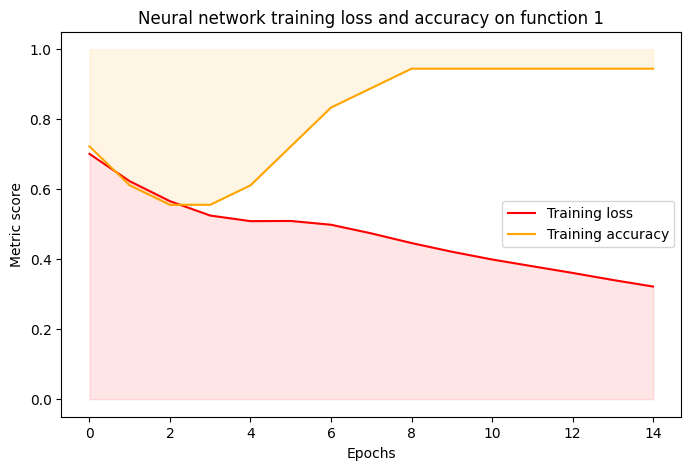

In [79]:
# ==== Creating neural network for function 7 ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Creating training tensors
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
X_tensor, y_tensor, y_class = training_tensors(X, y)

# Defining model architecture
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
input_dim = X.shape[1]
hidden_dim = len(X)

model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),       # Linear input layer
    nn.ReLU(),                      # ReLU activation
    nn.Linear(hidden_dim, hidden_dim),               # 2nd linear layer
    nn.ReLU(),                      # ReLU activation
    nn.Linear(hidden_dim, 1),                # Linear output layer
    nn.Sigmoid()                    # Sigmoid activation - for binary classification    
)


# Defining model hyperparameters
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
criterion = nn.BCELoss()
optimiser = optim.Adam(model.parameters(), lr=0.02)
epochs = 15

# Running model through iterative cycle
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
model, y_pred_nn, loss_history, accuracy_history = train_nn(X_tensor, y_tensor, y_class, model, epochs, criterion, optimiser)


# Creating X candidates and predicting
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

sampler = qmc.Sobol(6) # Using smarter sampling
X_candidates = sampler.random(2**15)

with torch.no_grad(): # Disable gradients for faster computation
    X_candidates_tensor = torch.from_numpy(X_candidates).float()

    X_candidates_prob_tensor = model(X_candidates_tensor)
    X_candidates_prob = X_candidates_prob_tensor.cpu().numpy().ravel()

# Plotting neural network performance
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
epochs_array = np.arange(0,epochs,1)
plot_nn(epochs_array, loss_history, accuracy_history, 1)


The next query point is: [0.039911 0.438004 0.443743 0.124676 0.450555 0.599792]

Submission format:        0.039911-0.438004-0.443743-0.124676-0.450555-0.599792

The best y value observed so far is: 1.9128291956464583 at iteration 34, with inputs [0.033248 0.479355 0.417031 0.228403 0.352995 0.620073]


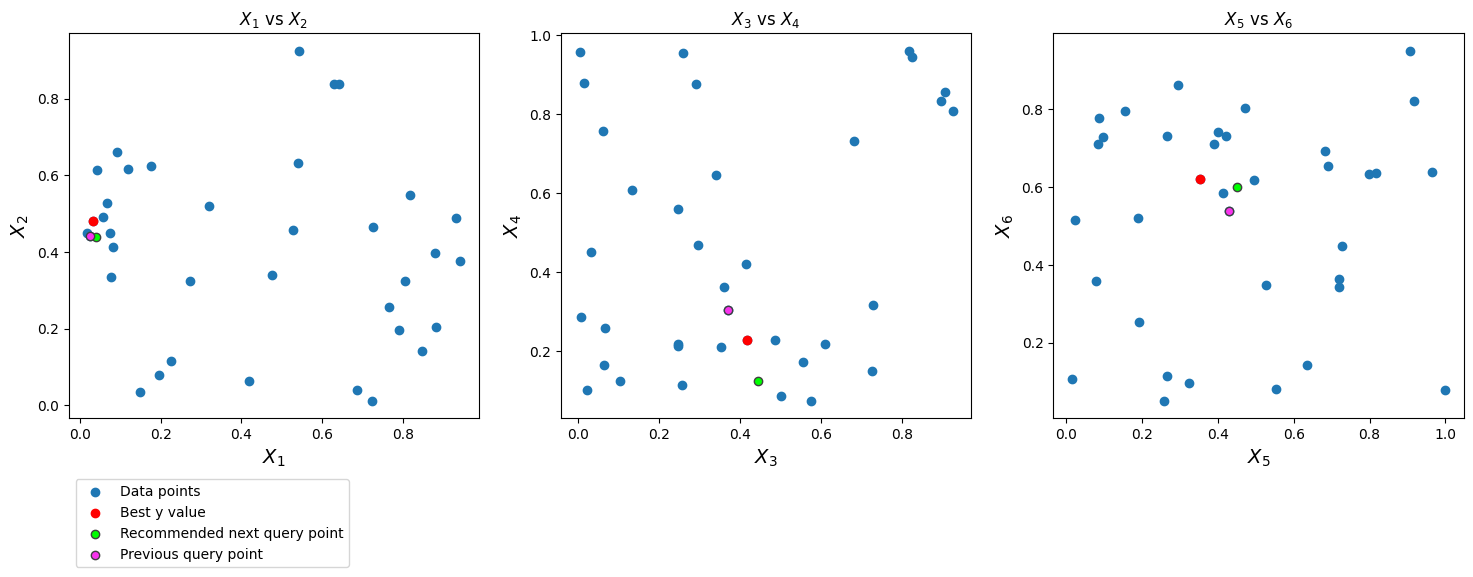

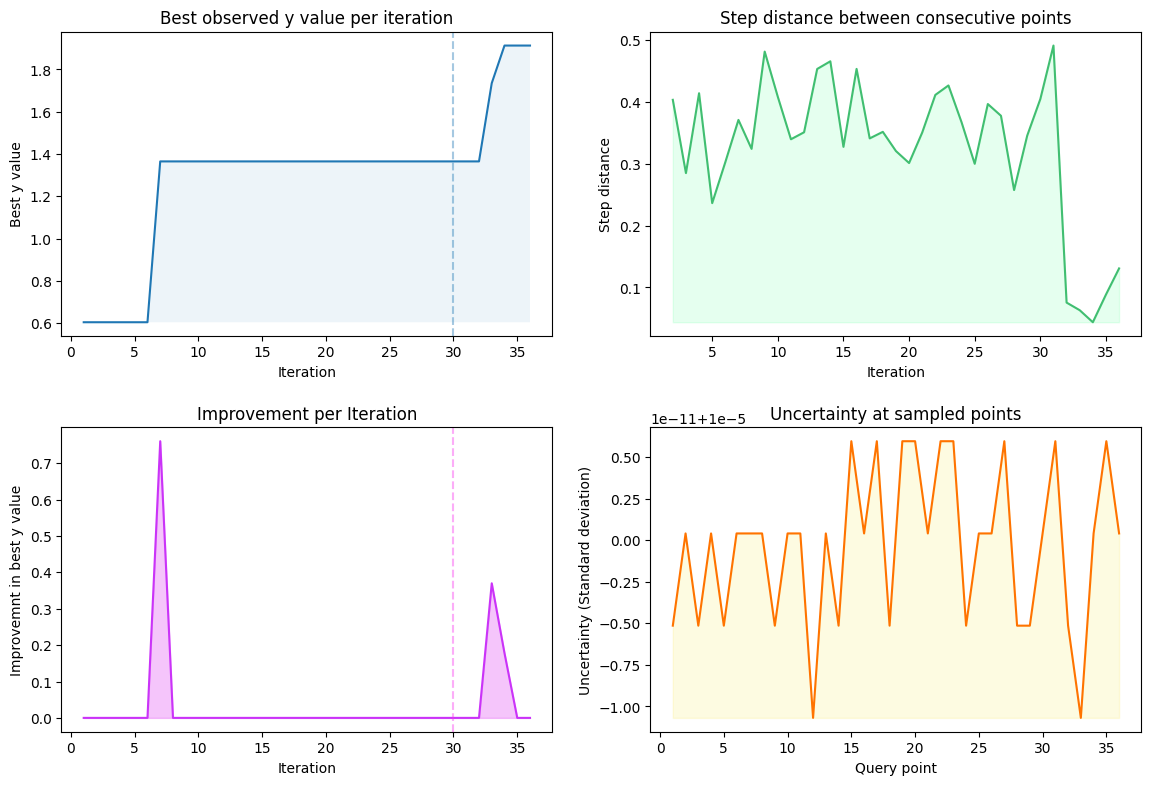

In [80]:
# Defining GP model and fitting to data
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
kernel = ConstantKernel(1.0) * Matern(length_scale=1, nu=2.5)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y_scaled)

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 1
acquisition_function = (mu + kappa * sigma) * (0.5 + 0.5 * X_candidates_prob)  

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]
print('The next query point is:', np.round(x_next,6))

submission = f"{x_next[0]:.6f}-{x_next[1]:.6f}-{x_next[2]:.6f}-{x_next[3]:.6f}-{x_next[4]:.6f}-{x_next[5]:.6f}"
print('\nSubmission format:       ', submission)


# ==== Metrics ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

(best_value7_rolling, best_value7, best_value7_index, best_value7_inputs, 
improvement, step_dist, step_dist_normalised, step_dist_min) = performance_metrics(X, y)

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)


# ==== Visualisation ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Scatter plots
scatter_plot_pairs = np.array([[1,2],   # X1 vs X2
                               [3,4],   # X1 vs X3
                               [5,6]])  # X1 vs X4
scatter_plots(scatter_plot_pairs, X, x_next, best_value7_inputs, manual_search=None)

# Performance tracking plots
performance_plots(X, 30, best_value7_rolling, improvement, 
                      step_dist_normalised, step_dist, step_dist_min, sigma_selected)

plt.show()

## <ins>Function 8</ins>

**8-dimensional**

You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown. 
Your objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.

For example, imagine you’re tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (numerically encoded), optimiser type (encoded) and initial weight range. Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this score.

**Approach**:

Likely to be lots of local maximum, start with high kappa + random search, using matern kernel.

In [81]:
function8_inputs = np.load(f'C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week {current_week}/Function 8/function8_inputs_week{current_week}.npy')
print('Inputs: \n', function8_inputs)

function8_outputs = np.load(f'C:/Python/Ml and AI - Imperial/Capstone Project/Data Sets/Week {current_week}/Function 8/function8_outputs_week{current_week}.npy')
print('Outputs: \n',function8_outputs)

X = function8_inputs
y = function8_outputs

print(len(X), len(y))

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1,1)).ravel()

Inputs: 
 [[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.22698177 0.4

### Creating neural network using nn.Sequential

Epoch: 0, Loss: 0.6582184433937073, Accuracy: 0.6956521739130435
Epoch: 2, Loss: 0.47451984882354736, Accuracy: 0.8695652173913043
Epoch: 4, Loss: 0.4441758394241333, Accuracy: 0.9130434782608695
Epoch: 6, Loss: 0.3549191951751709, Accuracy: 0.9565217391304348
Epoch: 8, Loss: 0.29059645533561707, Accuracy: 1.0
Epoch: 10, Loss: 0.22482284903526306, Accuracy: 1.0
Epoch: 12, Loss: 0.18698547780513763, Accuracy: 1.0
Epoch: 14, Loss: 0.13887248933315277, Accuracy: 1.0
Epoch: 16, Loss: 0.1121380403637886, Accuracy: 0.9565217391304348
Epoch: 18, Loss: 0.07556065917015076, Accuracy: 1.0


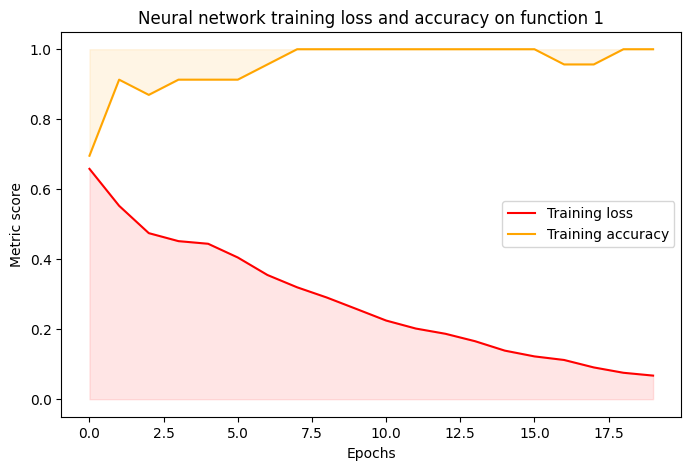

In [82]:
# ==== Creating neural network for function 8 ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Creating training tensors
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
X_tensor, y_tensor, y_class = training_tensors(X, y)

# Defining model architecture
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
input_dim = X.shape[1]
hidden_dim = len(X)

model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),       # Linear input layer
    nn.ReLU(),                      # ReLU activation
    nn.Linear(hidden_dim, hidden_dim),               # 2nd linear layer
    nn.ReLU(),                      # ReLU activation
    nn.Linear(hidden_dim, 1),                # Linear output layer
    nn.Sigmoid()                    # Sigmoid activation - for binary classification    
)


# Defining model hyperparameters
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
criterion = nn.BCELoss()
optimiser = optim.Adam(model.parameters(), lr=0.02)
epochs = 20

# Running model through iterative cycle
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
model, y_pred_nn, loss_history, accuracy_history = train_nn(X_tensor, y_tensor, y_class, model, epochs, criterion, optimiser)


# Creating X candidates and predicting
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

sampler = qmc.Sobol(8) # Using smarter sampling
X_candidates = sampler.random(2**15)

with torch.no_grad(): # Disable gradients for faster computation
    X_candidates_tensor = torch.from_numpy(X_candidates).float()

    X_candidates_prob_tensor = model(X_candidates_tensor)
    #X_candidates_prob = X_candidates_prob_tensor.detach().numpy()
    X_candidates_prob = X_candidates_prob_tensor.cpu().numpy().ravel()

# Plotting neural network performance
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
epochs_array = np.arange(0,epochs,1)
plot_nn(epochs_array, loss_history, accuracy_history, 1)


The next query point is: [0.01109  0.093106 0.124193 0.04225  0.85299  0.547946 0.170394 0.424396]

Submission format:        0.011090-0.093106-0.124193-0.042250-0.852990-0.547946-0.170394-0.424396

The best y value observed so far is: 9.907257279334 at iteration 45, with inputs [0.008468 0.141018 0.039291 0.055242 0.959507 0.40018  0.29406  0.463525]


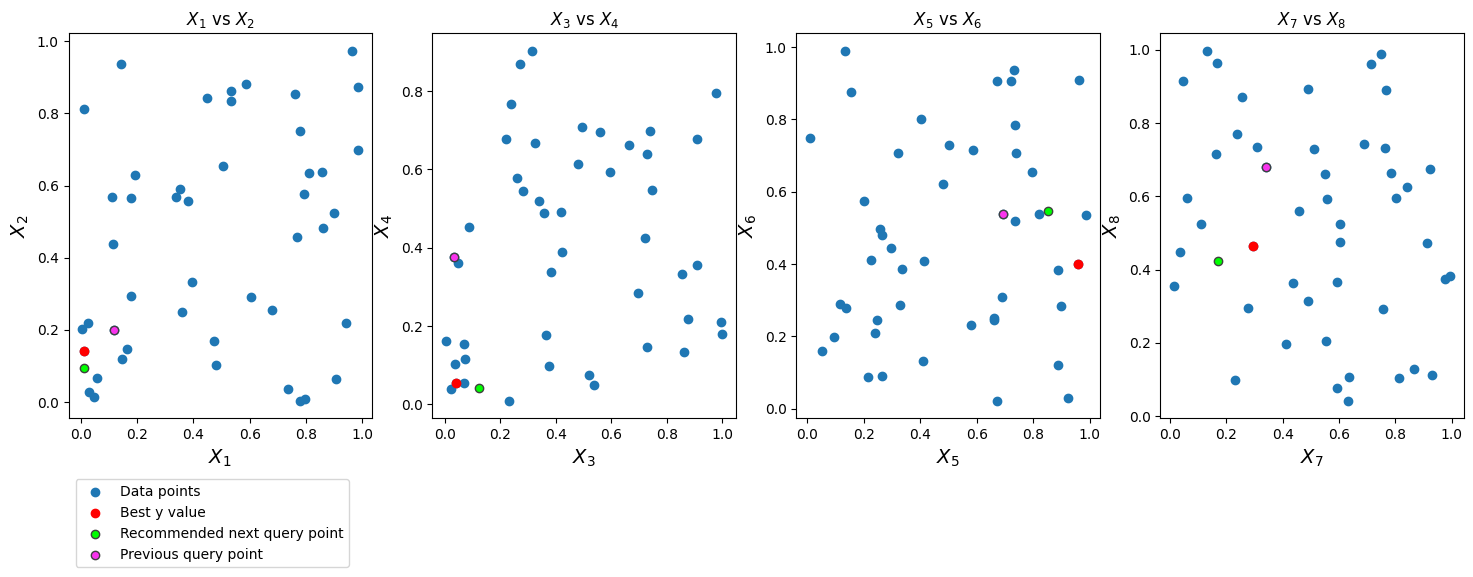

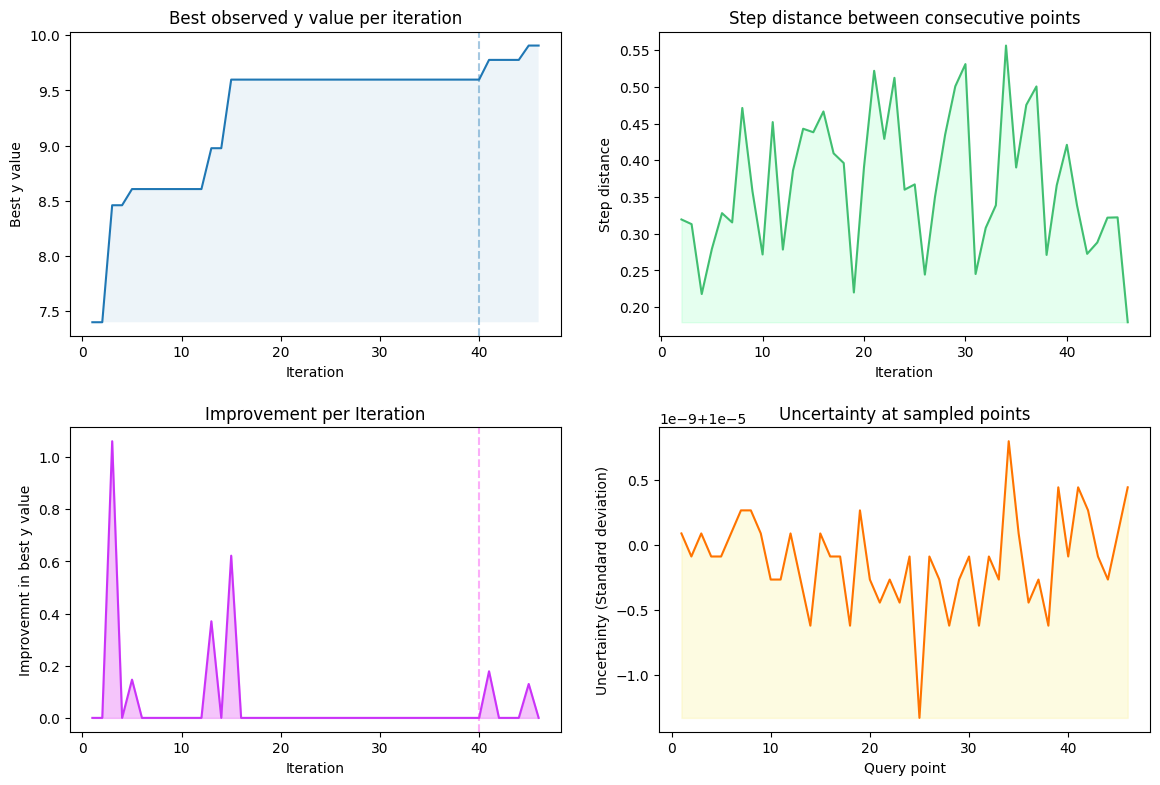

In [83]:
# Defining GP model and fitting to data
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

kernel = ConstantKernel(1.0) * Matern(length_scale=1, nu=2.5)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9) # Look at parameters, some are interesting like normalise y.

model = gpr.fit(X, y_scaled)

# GP predictions
mu, sigma = model.predict(X_candidates, return_std=True)

# Acquisition function (UCB)
kappa = 1
acquisition_function = (mu + kappa * sigma) * (0.5 + 0.5 * X_candidates_prob) 

# Pick next point
x_next = X_candidates[np.argmax(acquisition_function)]
print('The next query point is:', np.round(x_next,6))

submission = f"{x_next[0]:.6f}-{x_next[1]:.6f}-{x_next[2]:.6f}-{x_next[3]:.6f}-{x_next[4]:.6f}-{x_next[5]:.6f}-{x_next[6]:.6f}-{x_next[7]:.6f}"
print('\nSubmission format:       ', submission)


# ==== Metrics ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

(best_value8_rolling, best_value8, best_value8_index, best_value8_inputs, 
improvement, step_dist, step_dist_normalised, step_dist_min) = performance_metrics(X, y)

# Uncertainty at sampled points
mu_selected, sigma_selected = model.predict(X, return_std=True)


# ==== Visualisation ====
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾

# Scatter plots
scatter_plot_pairs = np.array([[1,2],   # X1 vs X2
                               [3,4],   # X3 vs X4
                               [5,6],   # X5 vs X6
                               [7,8]])  # X7 vs X8
scatter_plots(scatter_plot_pairs, X, x_next, best_value8_inputs, manual_search=None)

# Performance tracking plots
# ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
performance_plots(X, 40, best_value8_rolling, improvement, step_dist_normalised, step_dist, step_dist_min, sigma_selected)

plt.show()